## Trade&Ahead - Stock Segmentation using Clustering

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximize earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones that exhibit minimum correlation. This helps investors better analyze stocks across different market segments and helps protect against risks that could make the portfolio vulnerable to losses.

### Objective

Trade&Ahead is a financial consultancy firm that provides its customers with personalized investment strategies. The task is to analyze stock price data and financial indicators, group the stocks based on the attributes provided, and share insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Security: Name of the company
- GICS Sector: The specific economic sector assigned to a company that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity
- Cash Ratio: The ratio of a company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share to its book value per share

## Importing necessary libraries and data

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# To perform K-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# To visualize the silhouette scores of clusters
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# To perform hierarchical clustering, compute cophenetic correlation and create dendrograms
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering

# To perform PCA for dimensionality reduction
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
# loading the dataset
data = pd.read_csv("stock_data.csv")

## Data Overview

In [3]:
# viewing the shape of the dataset
data.shape

(513, 15)

In [4]:
# copying the data to another variable to avoid any changes to the original data
df = data.copy()

In [5]:
# viewing a random sample of the dataset
df.sample(n=10, random_state=1)

,Ticker_Symbol,Security,GICS_Sector,GICS_Sub_Industry,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio
47,TECH,Bio-Techne,Health Care,Life Sciences Tools & Services,70.830002,31.897972,6.825984,5.340000,67.245584,2.998494e+08,1.094990e+08,0.700000,1.558107e+08,101.185720,5.490272
346,TKO,TKO Group Holdings,Communication Services,Movies & Entertainment,194.419998,-0.934827,8.545262,6.736000,14.872812,8.309045e+08,2.263460e+08,2.680000,7.496767e+07,72.544780,4.317087
284,PNW,Pinnacle West Capital,Utilities,Multi-Utilities,109.370003,7.680067,2.386410,9.559000,0.030689,-8.311028e+08,6.540950e+08,5.360000,1.211872e+08,20.404850,1.875182
221,LDOS,Leidos,Industrials,Diversified Support Services,108.839996,-31.507833,17.876609,30.579000,6.372891,1.194750e+09,1.413000e+09,10.930000,1.257855e+08,9.957913,2.730968
504,DLF.NS,DLF Limited,Real Estate,Real Estate - Development,7.099790,27.721090,26.324279,10.031000,59.815125,5.529686e+08,4.637269e+08,0.187395,2.475312e+09,37.886772,3.682697
168,GE,GE Aerospace,Industrials,Aerospace & Defense,377.519989,30.770025,29.013864,45.428002,15.660297,5.668000e+09,8.564000e+09,8.040000,1.043337e+09,46.955223,21.813139
223,LII,Lennox International,Industrials,Building Products,570.030029,25.971949,26.766258,76.791000,2.698315,1.871375e+08,7.934000e+08,22.520000,3.479997e+07,25.312168,16.346352
189,HUBB,Hubbell Incorporated,Industrials,Industrial Machinery & Supplies & Components,487.100006,-2.130644,28.137587,25.822002,17.517025,5.414500e+08,9.043000e+08,16.900000,5.284178e+07,28.822487,6.829877
379,WEC,WEC Energy Group,Utilities,Electric Utilities,118.830002,2.671087,2.401258,11.679000,0.139129,-2.067012e+09,1.637700e+09,4.990000,3.257257e+08,23.813630,2.840852
192,IEX,IDEX Corporation,Industrials,Industrial Machinery & Supplies & Components,223.820007,17.748741,9.053375,12.748000,24.794857,5.250250e+08,5.077000e+08,6.760000,7.401505e+07,33.109467,4.106337


In [6]:
# checking datatypes and number of non-null values for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker_Symbol                 513 non-null    str    
 1   Security                      513 non-null    str    
 2   GICS_Sector                   513 non-null    str    
 3   GICS_Sub_Industry             513 non-null    str    
 4   Current_Price                 513 non-null    float64
 5   Price_Change                  513 non-null    float64
 6   Volatility                    513 non-null    float64
 7   ROE                           513 non-null    float64
 8   Cash_Ratio                    513 non-null    float64
 9   Net_Cash_Flow                 513 non-null    float64
 10  Net_Income                    513 non-null    float64
 11  Earnings_Per_Share            513 non-null    float64
 12  Estimated_Shares_Outstanding  513 non-null    float64
 13  P/E_Ratio       

- Ticker_Symbol, Security, GICS_Sector and GICS_Sub_Industry are of object type, and the rest are float type
- There are no null values in the dataset

In [7]:
# fixing column names, in case of any leading/trailing spaces
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

The dataset combines US and India-listed securities. During data collection, most dollar-denominated fields for the India-listed (`.NS`) tickers were already converted from INR to USD, but `Earnings_Per_Share` was left in raw INR for those tickers. This is corrected below before any further analysis, so that all monetary fields are on the same USD scale.

In [8]:
# correcting Earnings_Per_Share for India-listed (.NS) tickers, which was
# left in raw INR while other dollar fields were already converted to USD
FX_FACTOR = 95.2  # USD-INR rate used at the time of data collection

is_indian_ticker = df["Ticker_Symbol"].str.contains(".NS", regex=False, na=False)
df.loc[is_indian_ticker, "Earnings_Per_Share"] = (
    df.loc[is_indian_ticker, "Earnings_Per_Share"] / FX_FACTOR
)

print("Corrected Earnings_Per_Share for", is_indian_ticker.sum(), "India-listed tickers")

Corrected Earnings_Per_Share for 120 India-listed tickers


In [9]:
# Ticker_Symbol is an identifier and is not required for the clustering analysis
df.drop("Ticker_Symbol", axis=1, inplace=True)

In [10]:
# checking for duplicate records
df.duplicated().sum()

np.int64(0)

In [11]:
# checking for duplicate securities
df["Security"].duplicated().sum()

np.int64(0)

- There are no duplicate records or duplicate securities in the dataset

In [12]:
# checking total null values
df.isnull().sum()

Security                        0
GICS_Sector                     0
GICS_Sub_Industry               0
Current_Price                   0
Price_Change                    0
Volatility                      0
ROE                             0
Cash_Ratio                      0
Net_Cash_Flow                   0
Net_Income                      0
Earnings_Per_Share              0
Estimated_Shares_Outstanding    0
P/E_Ratio                       0
P/B_Ratio                       0
dtype: int64

- There are no missing values in the dataset

In [13]:
# statistical summary of the data
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Security,513,513,3M,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS_Sector,513,17,Industrials,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS_Sub_Industry,513,152,Health Care Equipment,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current_Price,513.0,NaN,NaN,NaN,195.057219,372.303599,0.76208,40.470001,111.839996,235.550003,6750.790039
Price_Change,513.0,NaN,NaN,NaN,10.253956,22.941514,-37.630694,-1.625448,6.870324,18.270494,158.248616
Volatility,513.0,NaN,NaN,NaN,57.779801,242.750685,0.190161,4.766784,10.651605,34.118047,4367.871505
ROE,513.0,NaN,NaN,NaN,47.337405,382.359533,-0.768,10.059,16.986,30.579,8457.143
Cash_Ratio,513.0,NaN,NaN,NaN,66.543271,183.901738,0.022945,5.431411,17.31123,52.075967,1946.325697
Net_Cash_Flow,513.0,NaN,NaN,NaN,2173140485.435716,6912022529.489378,-28243374080.0,139812242.465054,986047232.0,2446874880.0,101090746368.0
Net_Income,513.0,NaN,NaN,NaN,4256957167.130164,15586999866.720503,-605000000.0,454343522.463723,1216999936.0,2900300032.0,160207994880.0


- The dataset covers companies across multiple GICS sectors
- Several numerical columns (Volatility, ROE, Cash_Ratio, Net_Income, Estimated_Shares_Outstanding) show a very large gap between the mean and the median along with a big difference between the 75th percentile and the maximum value. This is a strong sign of extreme outliers that will need to be treated before clustering, otherwise a few extreme companies will distort the distance-based clustering algorithms

## Data Cleaning

Since this dataset has been pulled together from a live source, the sector labels are not perfectly standardized against the original GICS taxonomy (for example, some companies show up as "Healthcare" instead of "Health Care", or "Technology" instead of "Information Technology"). Before doing any sector-level analysis, these labels are standardized so that each sector is counted correctly.

In [14]:
# checking the raw sector labels before cleaning
df["GICS_Sector"].value_counts()

GICS_Sector
Industrials               88
Information Technology    68
Health Care               47
Utilities                 43
Real Estate               36
Consumer Discretionary    33
Energy                    28
Consumer Staples          27
Financials                25
Materials                 22
Communication Services    19
Healthcare                19
Consumer Cyclical         17
Technology                15
Consumer Defensive        12
Basic Materials           10
Financial Services         4
Name: count, dtype: int64

In [15]:
# mapping non-standard sector labels to their standard GICS_Sector equivalent
sector_mapping = {
    "Healthcare": "Health Care",
    "Consumer Cyclical": "Consumer Discretionary",
    "Technology": "Information Technology",
    "Consumer Defensive": "Consumer Staples",
    "Basic Materials": "Materials",
    "Financial Services": "Financials",
}

df["GICS_Sector"] = df["GICS_Sector"].replace(sector_mapping)

# checking sector labels after cleaning
df["GICS_Sector"].value_counts()

GICS_Sector
Industrials               88
Information Technology    83
Health Care               66
Consumer Discretionary    50
Utilities                 43
Consumer Staples          39
Real Estate               36
Materials                 32
Financials                29
Energy                    28
Communication Services    19
Name: count, dtype: int64

- After cleaning, the sector labels are consistent with the standard GICS classification, which makes the sector-level EDA and cluster profiling reliable

In [16]:
# checking for any leading/trailing spaces or inconsistent casing in GICS_Sub_Industry
df["GICS_Sub_Industry"] = df["GICS_Sub_Industry"].str.strip()
df["GICS_Sub_Industry"].nunique()

152

## Exploratory Data Analysis (EDA)

In [17]:
# function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )
    plt.show()

In [18]:
# selecting numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols

['Current_Price',
 'Price_Change',
 'Volatility',
 'ROE',
 'Cash_Ratio',
 'Net_Cash_Flow',
 'Net_Income',
 'Earnings_Per_Share',
 'Estimated_Shares_Outstanding',
 'P/E_Ratio',
 'P/B_Ratio']

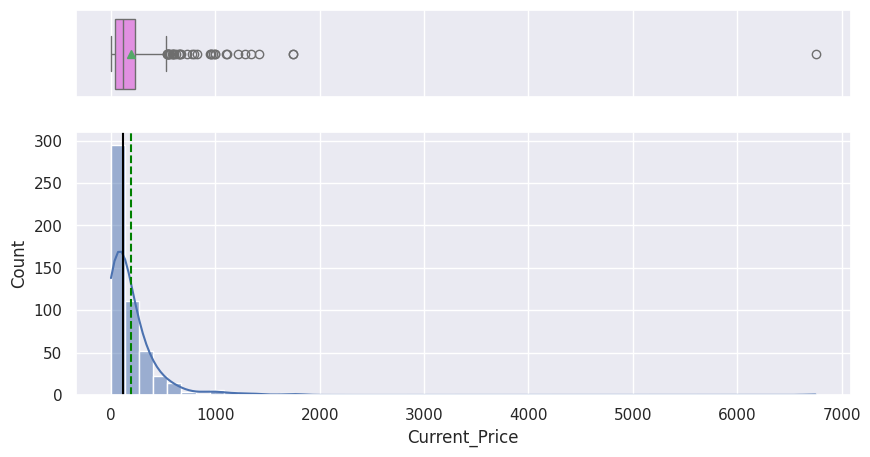

In [19]:
histogram_boxplot(df, "Current_Price", bins=50, kde=True, figsize=(10, 5))

- Current_Price is heavily right skewed with several very high positive outliers

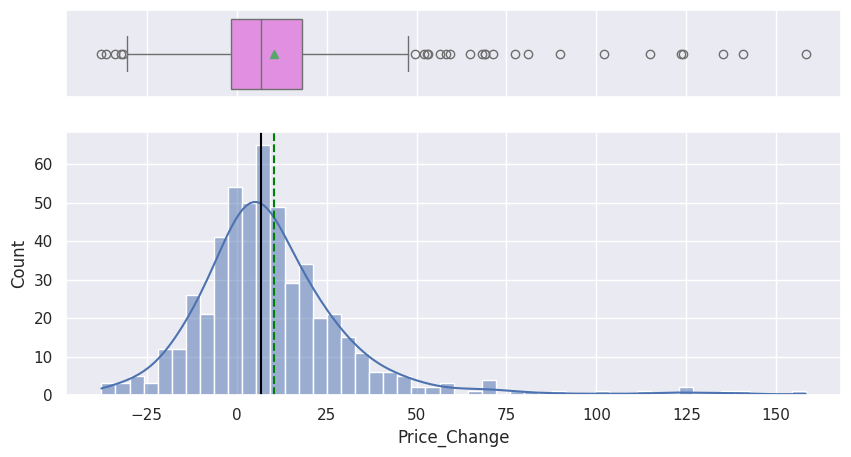

In [20]:
histogram_boxplot(df, "Price_Change", bins=50, kde=True, figsize=(10, 5))

- Price_Change is close to a normal distribution with a few positive and negative outliers

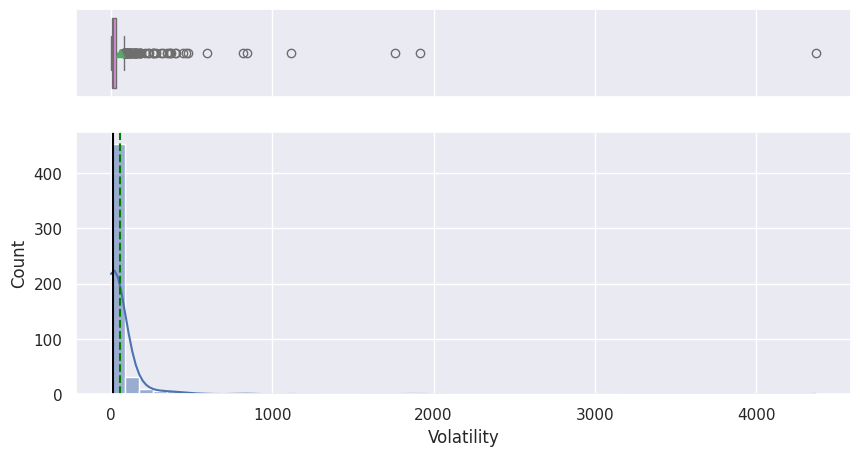

In [21]:
histogram_boxplot(df, "Volatility", bins=50, kde=True, figsize=(10, 5))

- Volatility is heavily right skewed with a small number of extreme positive outliers

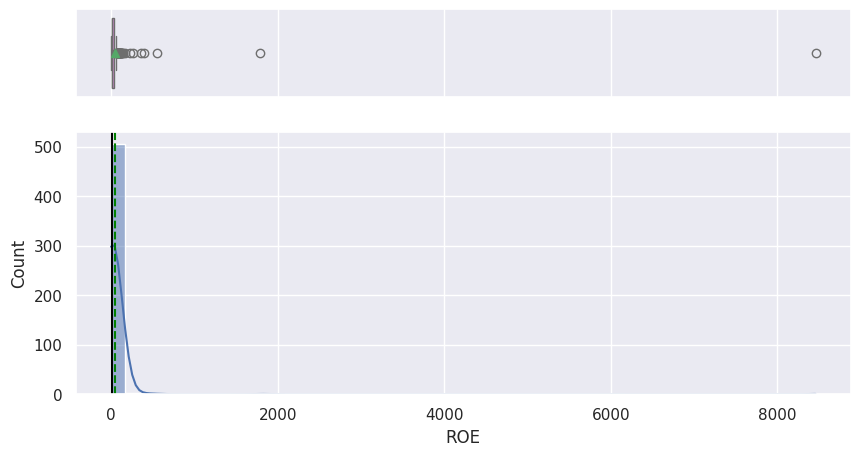

In [22]:
histogram_boxplot(df, "ROE", bins=50, kde=True, figsize=(10, 5))

- ROE is heavily right skewed with a small number of extreme positive outliers

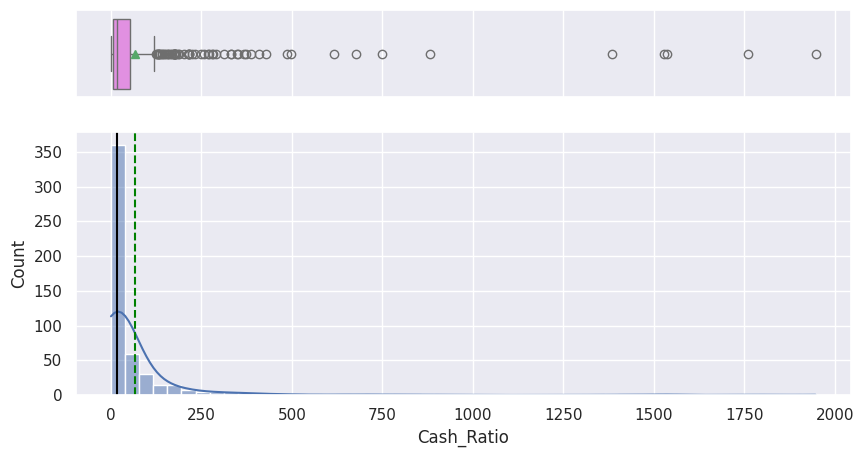

In [23]:
histogram_boxplot(df, "Cash_Ratio", bins=50, kde=True, figsize=(10, 5))

- Cash_Ratio is right skewed with several positive outliers

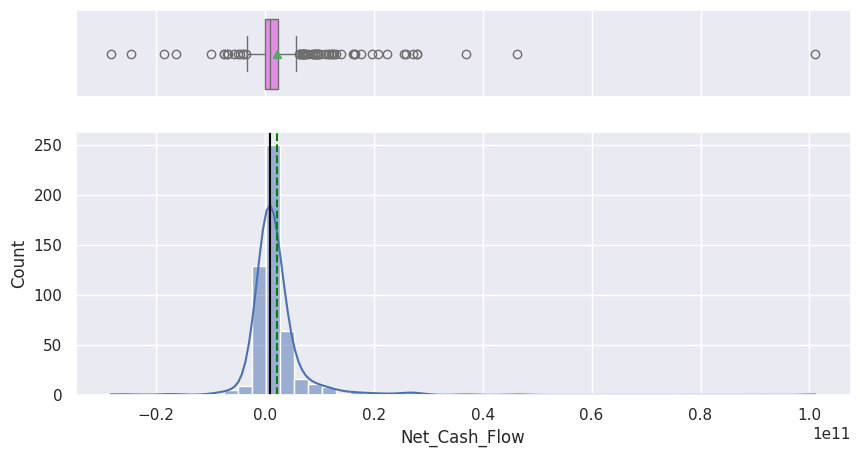

In [24]:
histogram_boxplot(df, "Net_Cash_Flow", bins=50, kde=True, figsize=(10, 5))

- Net_Cash_Flow is close to a normal distribution with positive and negative outliers

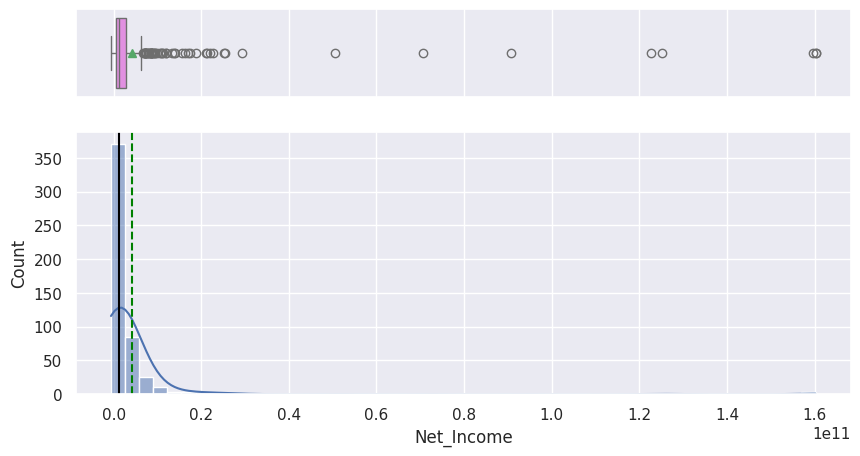

In [25]:
histogram_boxplot(df, "Net_Income", bins=50, kde=True, figsize=(10, 5))

- Net_Income is right skewed with some positive outliers

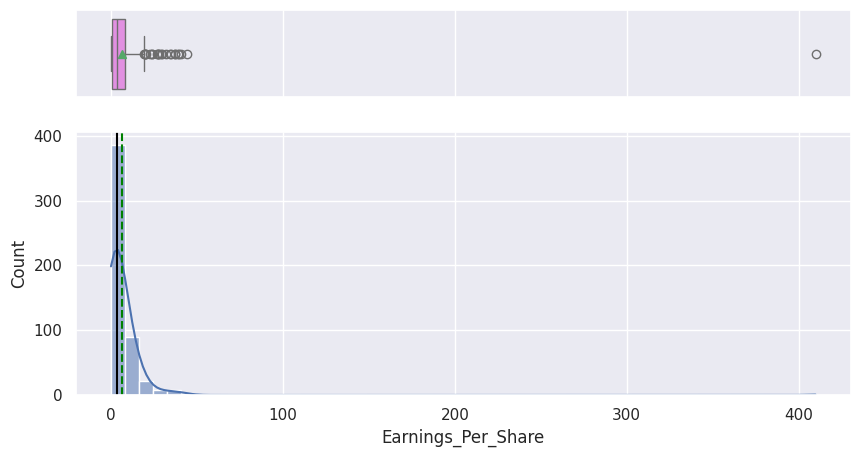

In [26]:
histogram_boxplot(df, "Earnings_Per_Share", bins=50, kde=True, figsize=(10, 5))

- Earnings_Per_Share is right skewed with some positive outliers

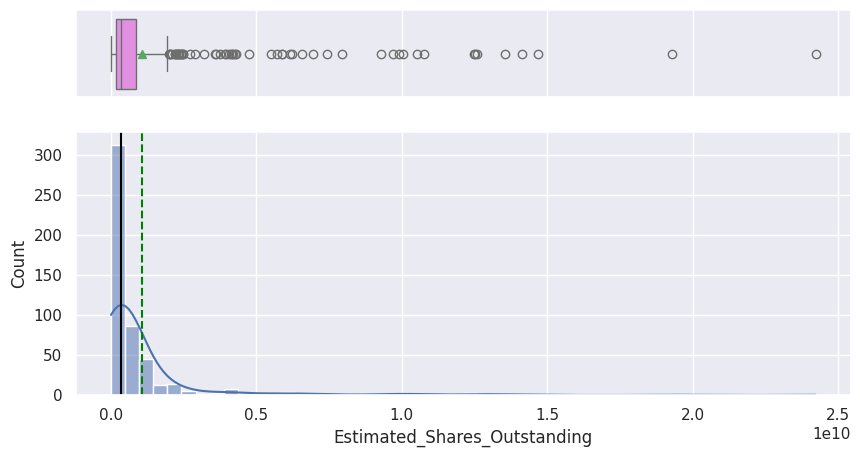

In [27]:
histogram_boxplot(df, "Estimated_Shares_Outstanding", bins=50, kde=True, figsize=(10, 5))

- Estimated_Shares_Outstanding is right skewed with several positive outliers

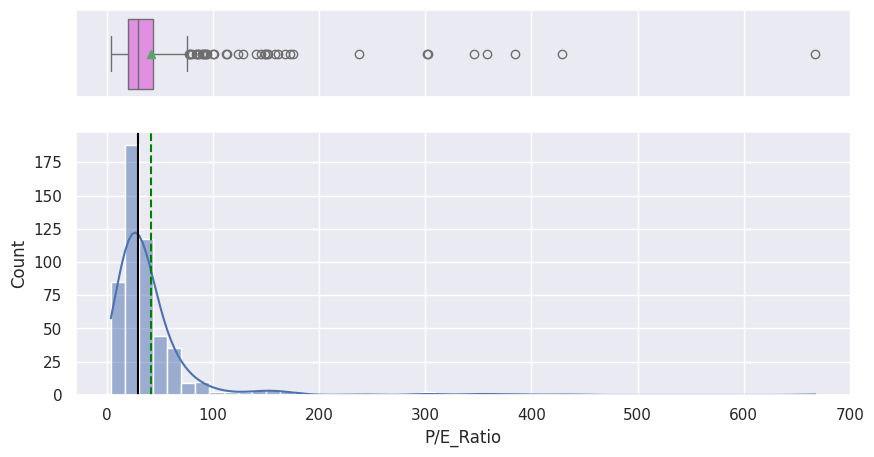

In [28]:
histogram_boxplot(df, "P/E_Ratio", bins=50, kde=True, figsize=(10, 5))

- P/E_Ratio is right skewed with some positive outliers

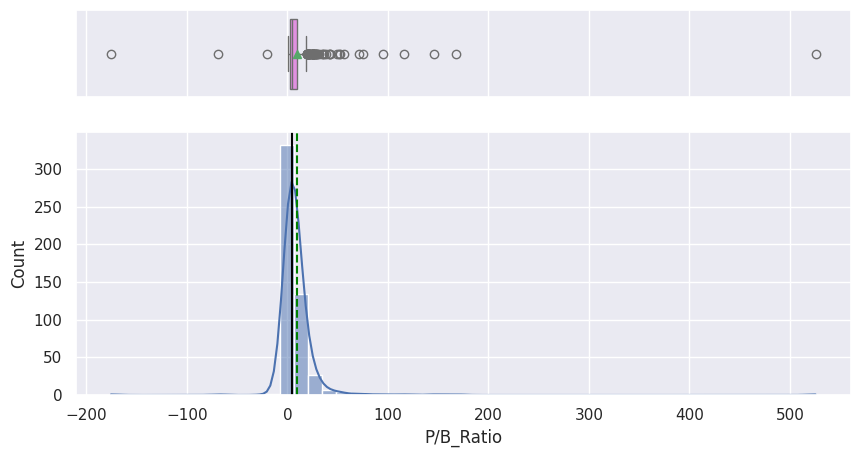

In [29]:
histogram_boxplot(df, "P/B_Ratio", bins=50, kde=True, figsize=(10, 5))

- P/B_Ratio is right skewed with a few positive outliers

In [30]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None, figsize=(15, 5)):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    figsize: size of figure
    """
    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=figsize)
    else:
        plt.figure(figsize=figsize)

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

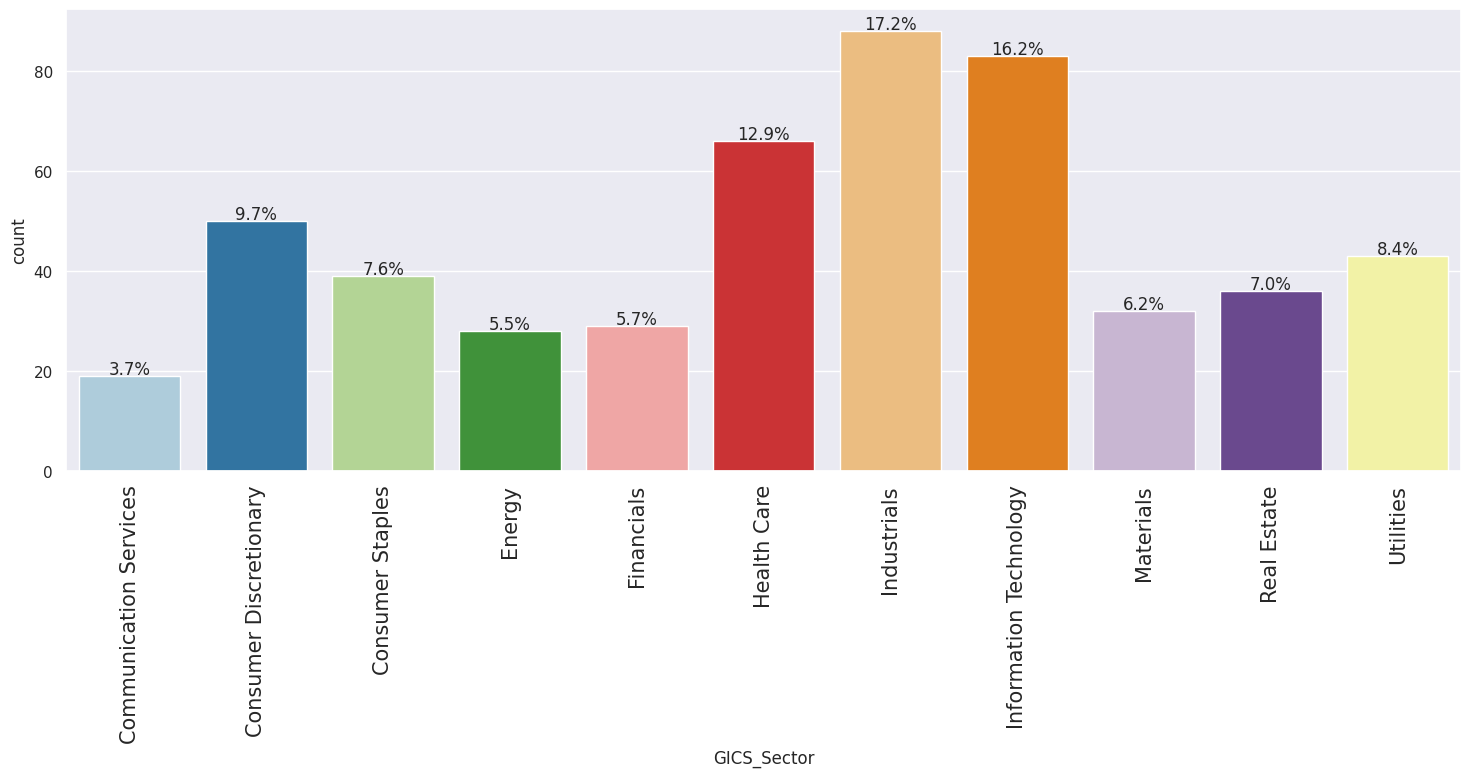

In [31]:
labeled_barplot(df, "GICS_Sector", perc=True, figsize=(18, 6))

- Industrials has the highest number of securities in the dataset, and the sector composition is fairly diversified across all 11 GICS sectors

In [32]:
# cross tabulation of sub-industry against sector, highlighting the sub-industry with the most securities in each sector
pd.crosstab(df.GICS_Sub_Industry, df.GICS_Sector).style.highlight_max(
    color="lightgreen", axis=0
)

GICS_Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
GICS_Sub_Industry,,,,,,,,,,,
Advertising,1,0,0,0,0,0,0,0,0,0,0
Aerospace & Defense,0,0,0,0,0,0,10,0,0,0,0
Agricultural & Farm Machinery,0,0,0,0,0,0,1,0,0,0,0
Agricultural Inputs,0,0,0,0,0,0,0,0,1,0,0
Agricultural Products & Services,0,0,2,0,0,0,0,0,0,0,0
Air Freight & Logistics,0,0,0,0,0,0,4,0,0,0,0
Aluminum,0,0,0,0,0,0,0,0,1,0,0
Apparel Manufacturing,0,1,0,0,0,0,0,0,0,0,0
Apparel Retail,0,2,0,0,0,0,0,0,0,0,0


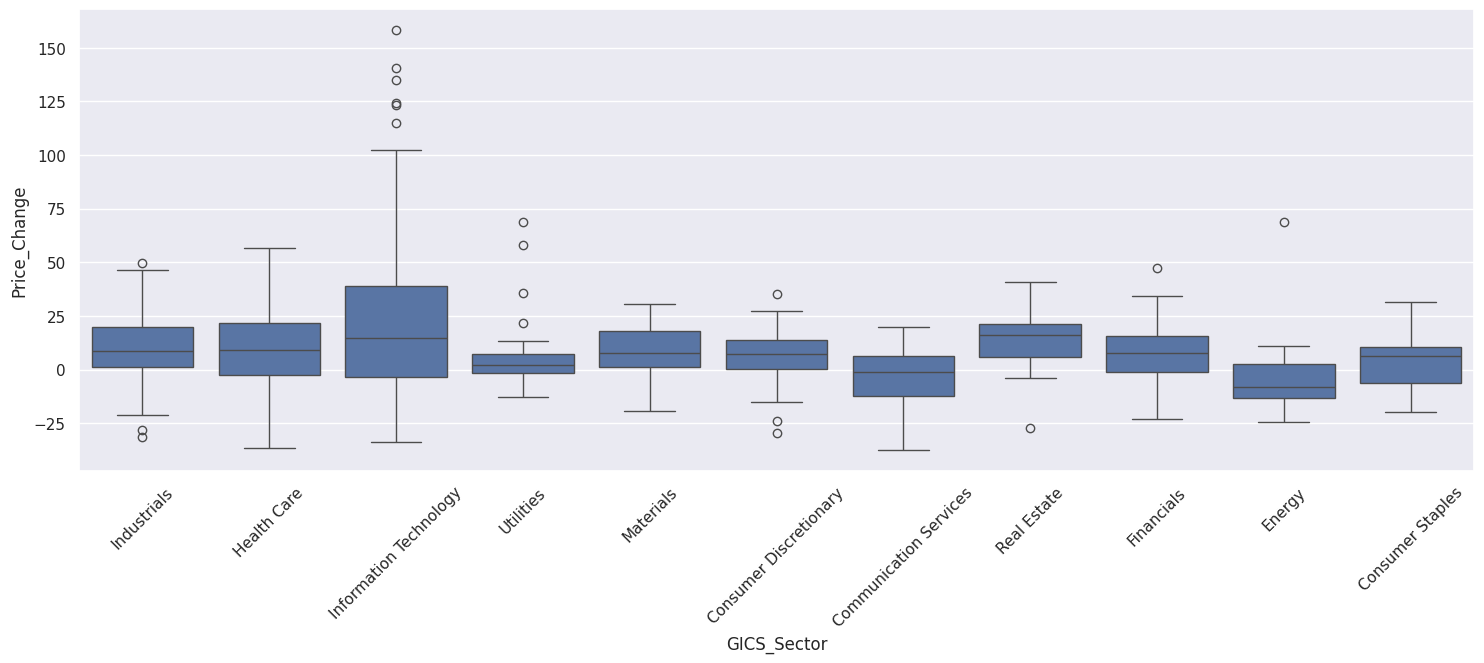

In [33]:
# Bivariate analysis - Price_Change vs. GICS_Sector
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, y="Price_Change", x="GICS_Sector")
plt.xticks(rotation=45)
plt.show()

- Some sectors have seen a wider spread of Price_Change over the last 13 weeks than others, which points to differences in sector-level risk and momentum

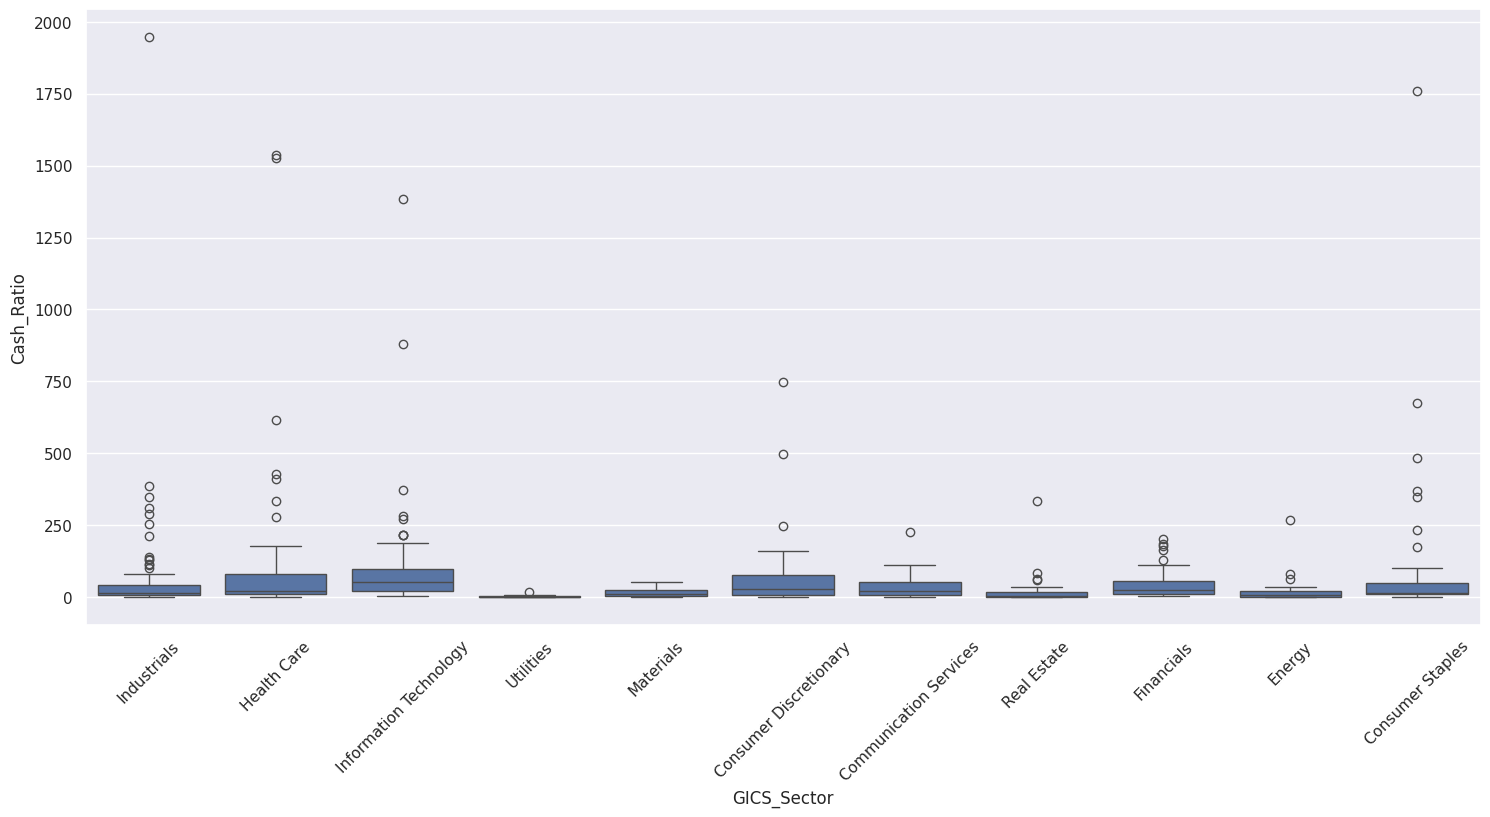

In [34]:
# Cash_Ratio vs. GICS_Sector
plt.figure(figsize=(18, 8))
sns.boxplot(data=df, y="Cash_Ratio", x="GICS_Sector")
plt.xticks(rotation=45)
plt.show()

- Sectors differ noticeably in how much cash they hold relative to current liabilities, which is a useful signal of financial safety

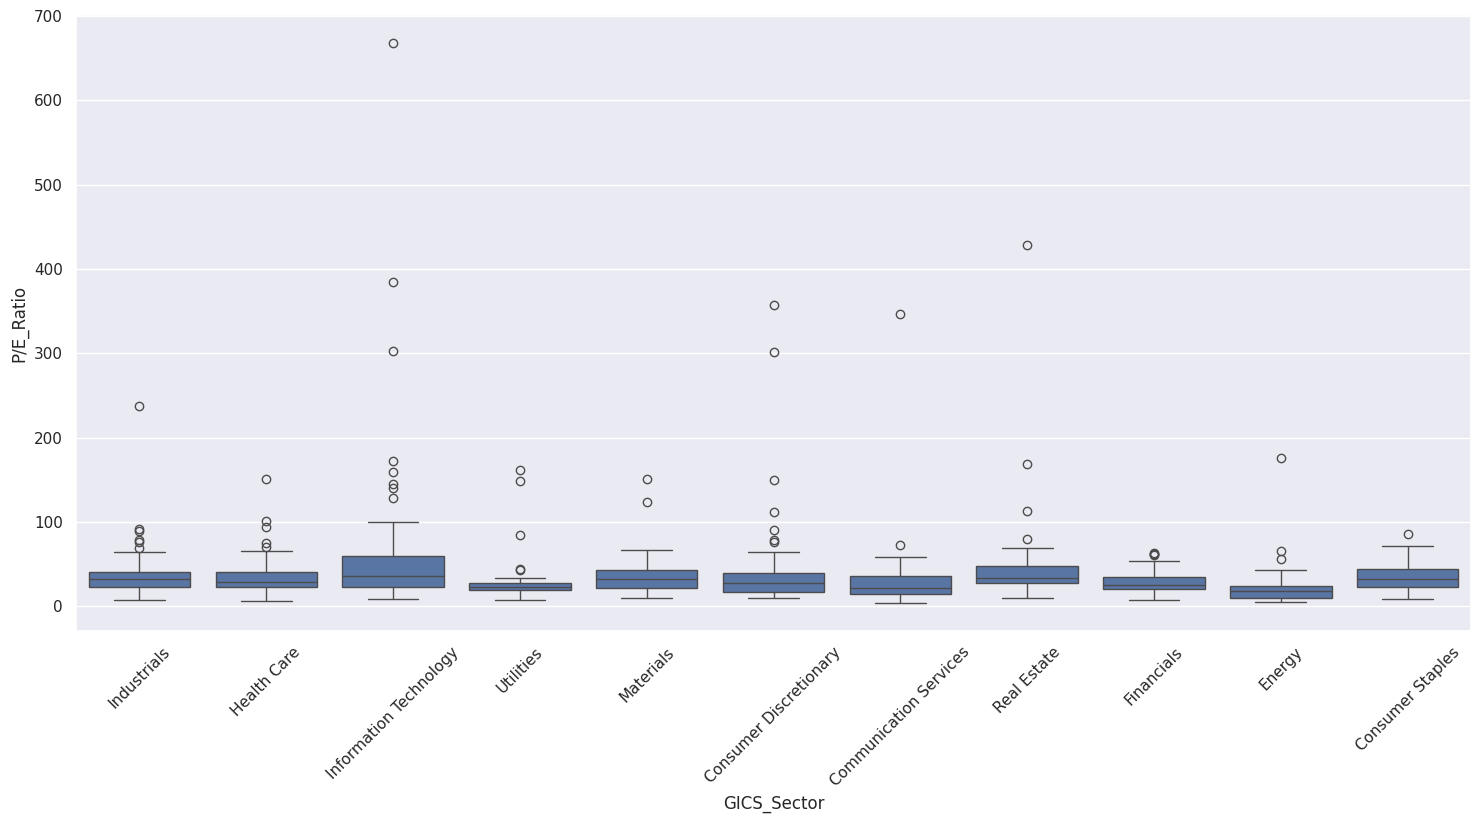

In [35]:
# P/E_Ratio vs. GICS_Sector
plt.figure(figsize=(18, 8))
sns.boxplot(data=df, y="P/E_Ratio", x="GICS_Sector")
plt.xticks(rotation=45)
plt.show()

- Some sectors show much higher and more variable P/E ratios, indicating investors are willing to pay more per dollar of earnings for companies in those sectors

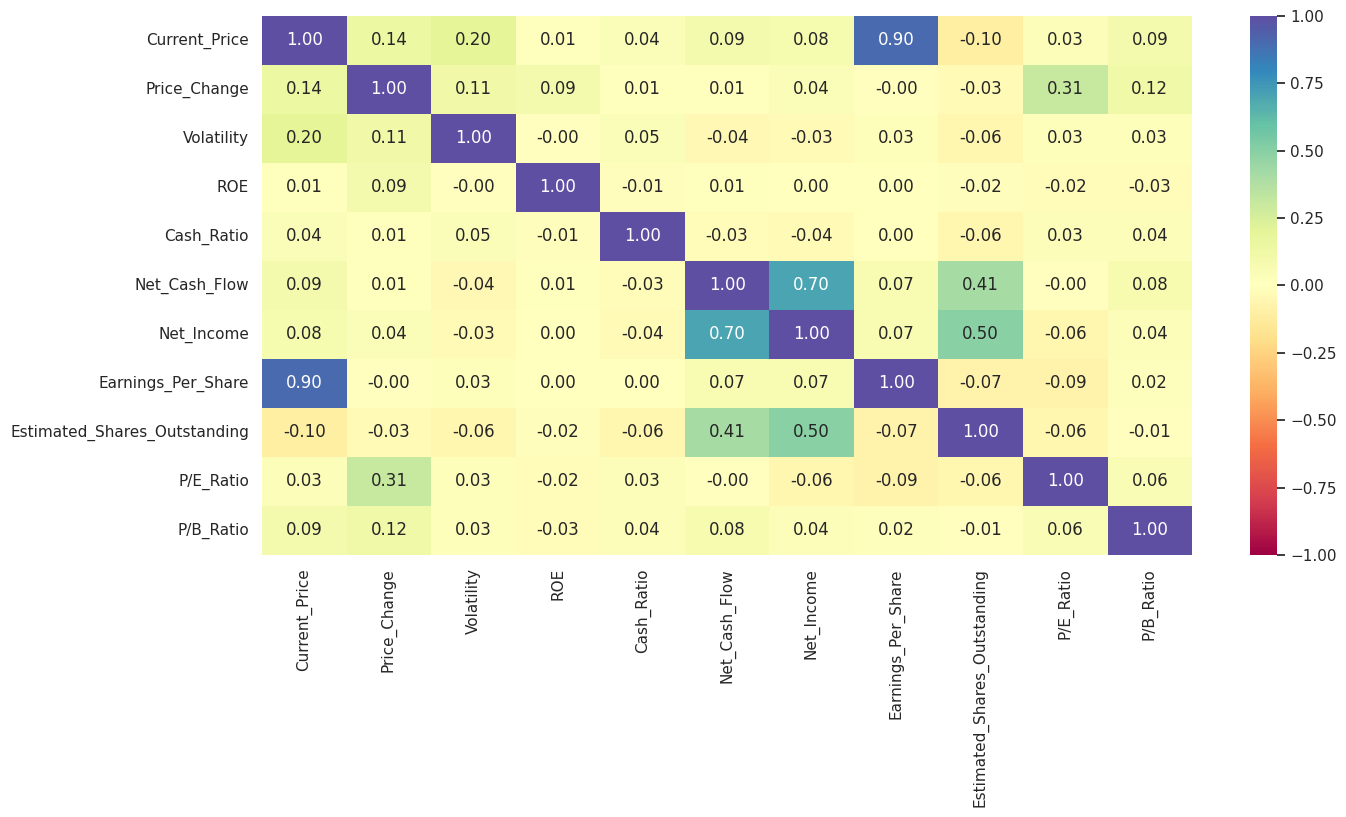

In [36]:
# checking correlations among the numerical attributes
plt.figure(figsize=(15, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- The correlation heatmap highlights which financial indicators move together and which are largely independent, which is useful context before scaling and clustering the data

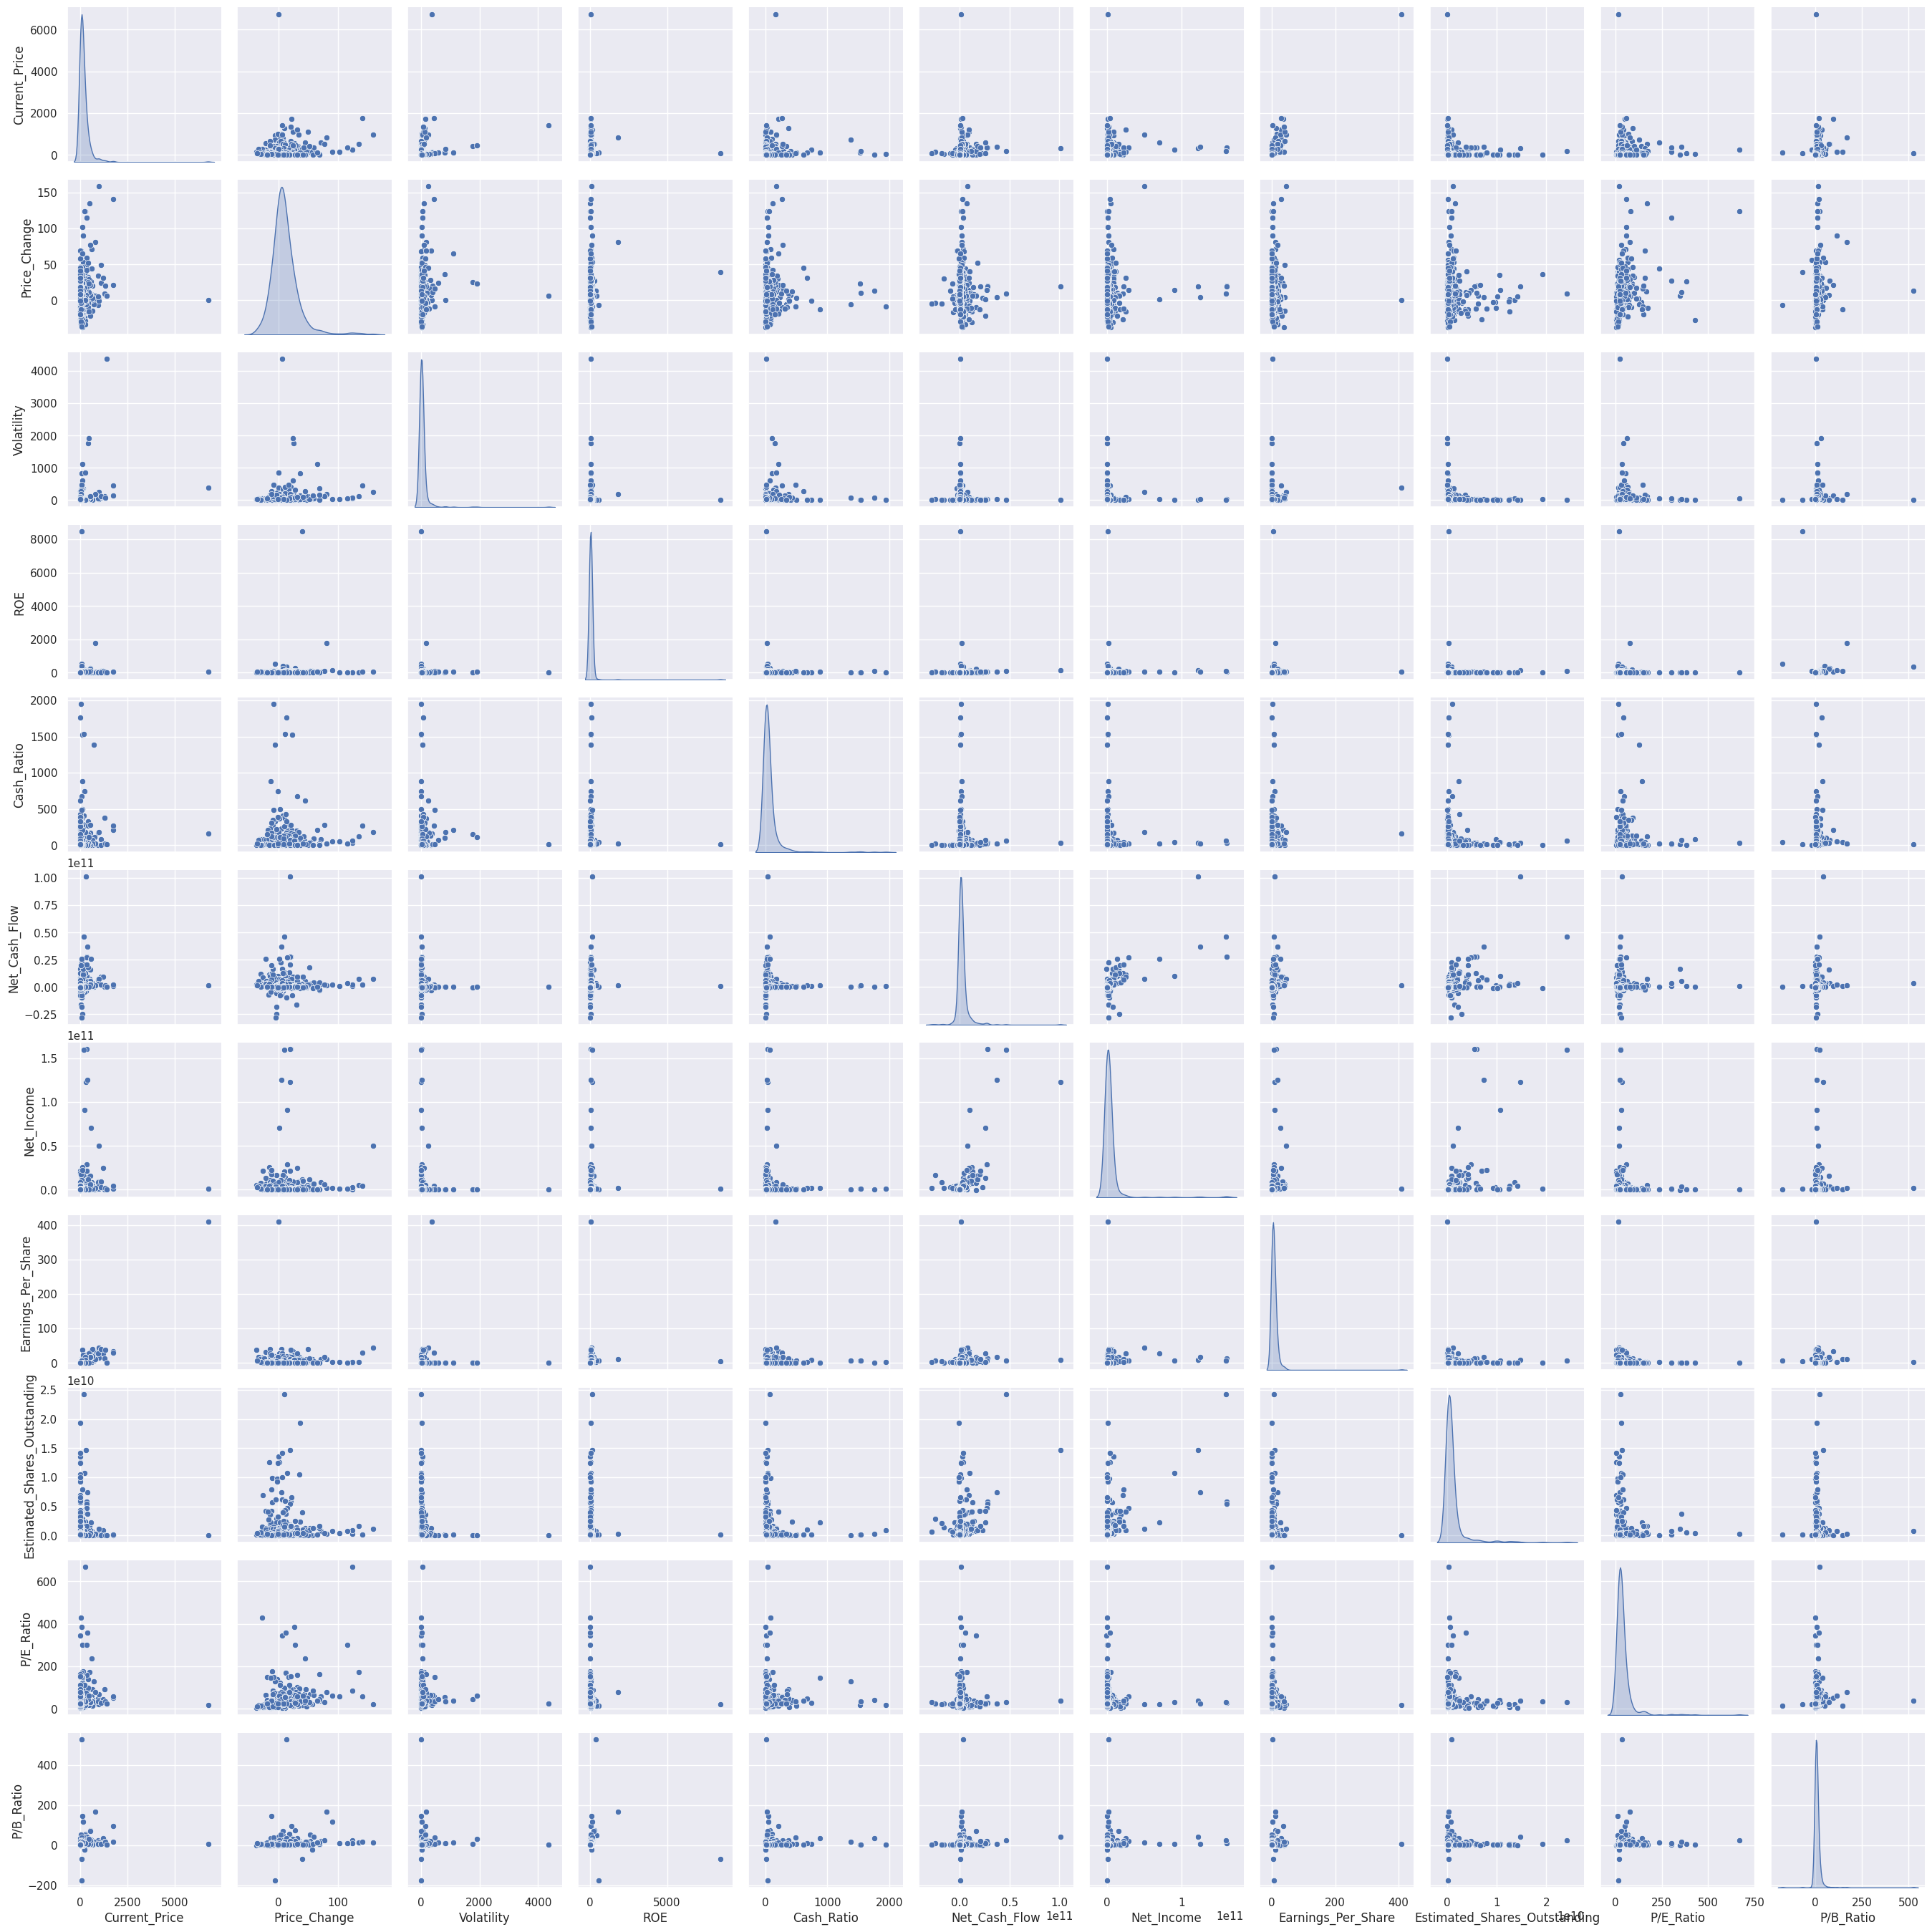

In [37]:
# Pair-plot analysis
sns.pairplot(df[num_cols], diag_kind="kde")
plt.show()

- Most numerical attributes are heavily skewed with extreme outliers, which confirms that outlier treatment is needed before applying a distance-based clustering algorithm

## Data Preprocessing

Since K-Means and Hierarchical clustering are both distance-based algorithms, a small number of extreme outliers can distort the distances between points and pull cluster centers away from where the bulk of the data actually sits. To get well-separated, meaningful clusters, outliers in the numerical columns are treated before scaling.

In [38]:
# function to cap outliers using the IQR method (winsorization)

def treat_outliers(data, col):
    """
    Caps outliers in a column at the lower and upper IQR whiskers

    data: dataframe
    col: column to treat
    """
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower_whisker, upper_whisker)
    return data

In [39]:
# counting how many outliers are present in each numerical column before treatment
outlier_count = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    outlier_count[col] = ((df[col] < lower_whisker) | (df[col] > upper_whisker)).sum()

pd.DataFrame.from_dict(outlier_count, orient="index", columns=["outlier_count"])

,outlier_count
Current_Price,35
Price_Change,27
Volatility,70
ROE,43
Cash_Ratio,61
Net_Cash_Flow,63
Net_Income,54
Earnings_Per_Share,24
Estimated_Shares_Outstanding,56
P/E_Ratio,39


In [40]:
# treating outliers in all numerical columns
df_treated = df.copy()
for col in num_cols:
    df_treated = treat_outliers(df_treated, col)

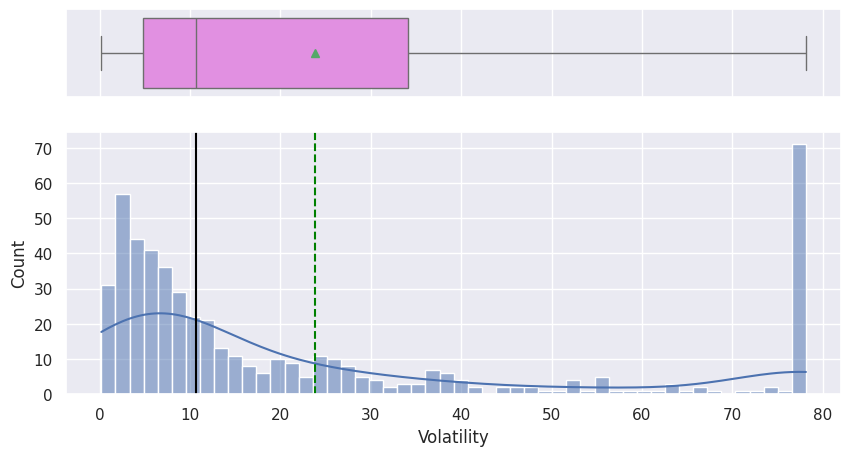

In [41]:
# comparing distribution before and after outlier treatment for a couple of columns
histogram_boxplot(df_treated, "Volatility", bins=50, kde=True, figsize=(10, 5))

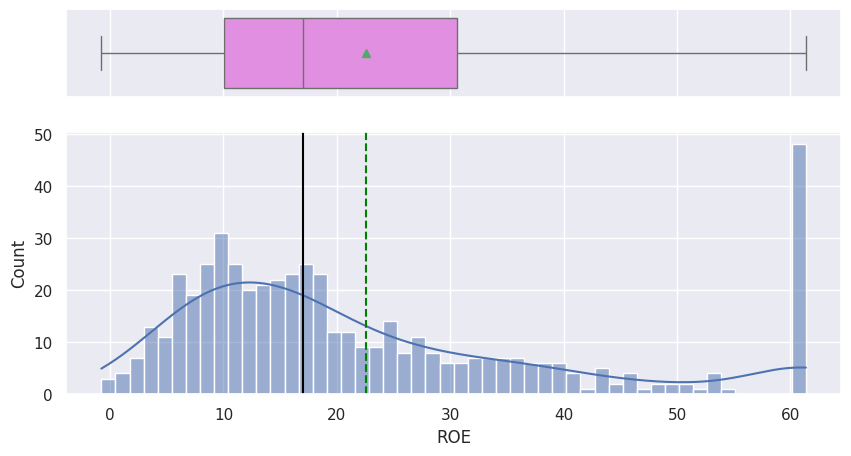

In [42]:
histogram_boxplot(df_treated, "ROE", bins=50, kde=True, figsize=(10, 5))

- After capping, the extreme values have been pulled in to the IQR whiskers instead of being removed, so no rows/companies are lost, while the distributions are far less skewed and more suitable for scaling and distance-based clustering

In [43]:
# scaling the data to bring all attributes to the same scale
sc = StandardScaler()
subset_scaled_df = pd.DataFrame(
    sc.fit_transform(
        df_treated.drop(["Security", "GICS_Sector", "GICS_Sub_Industry"], axis=1)
    ),
    columns=df_treated.drop(
        ["Security", "GICS_Sector", "GICS_Sub_Industry"], axis=1
    ).columns,
)
subset_scaled_df.head()

,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio
0,-0.000968,0.168789,-0.636968,2.309083,-0.481845,0.402532,0.375062,-0.032790,-0.143292,-0.160015,2.123253
1,-0.635133,-0.648940,-0.777842,0.340396,-0.370305,-0.443741,-0.726371,-0.289370,-0.825919,-0.907166,-0.363483
2,-0.423052,-0.862647,-0.710279,-0.607479,-0.453961,2.063376,2.064213,-0.321666,1.890324,-0.382901,-0.606182
3,-0.150813,-2.268687,-0.096752,0.110700,0.939106,2.063376,2.218861,1.285995,0.007324,-1.209413,-0.701886
4,0.383736,-1.090453,-0.127852,2.309083,1.021492,2.063376,2.218861,2.175950,-0.350057,-1.125461,0.153755


- All numerical attributes have been transformed to have a mean of 0 and a standard deviation of 1, so no single attribute dominates the distance calculation purely because of its scale

## K-Means Clustering

Number of Clusters: 1 	Average Distortion: 3.170148879435241
Number of Clusters: 2 	Average Distortion: 2.8527294754147787
Number of Clusters: 3 	Average Distortion: 2.6265247142593635
Number of Clusters: 4 	Average Distortion: 2.481549435954502
Number of Clusters: 5 	Average Distortion: 2.3775111348920177
Number of Clusters: 6 	Average Distortion: 2.304944343907318
Number of Clusters: 7 	Average Distortion: 2.2403063330773096
Number of Clusters: 8 	Average Distortion: 2.141384887338055


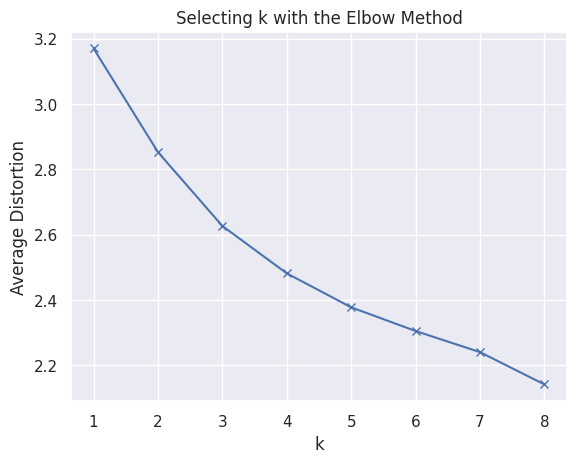

In [44]:
# finding the appropriate number of clusters using the elbow method
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1, n_init=10)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1))
        / subset_scaled_df.shape[0]
    )
    meanDistortions.append(distortion)
    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

For n_clusters = 2, silhouette score is 0.2296616790689359
For n_clusters = 3, silhouette score is 0.20160279498461212
For n_clusters = 4, silhouette score is 0.2047184209532693
For n_clusters = 5, silhouette score is 0.17739109002013048
For n_clusters = 6, silhouette score is 0.18508009022257407
For n_clusters = 7, silhouette score is 0.18089699387680566
For n_clusters = 8, silhouette score is 0.19811025916023972


For n_clusters = 9, silhouette score is 0.20982540557630178


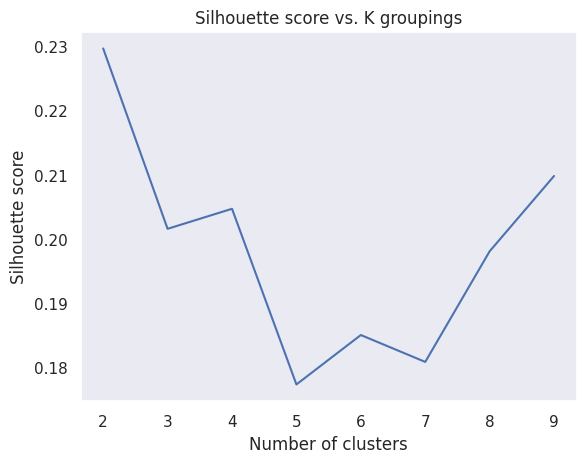

In [45]:
# checking silhouette scores for different values of k
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init=10)
    preds = clusterer.fit_predict(subset_scaled_df)
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs. K groupings")
plt.grid()
plt.show()

In [46]:
# function to plot per-sample silhouette scores for a fitted KMeans model

def silhouette_plot(data, n_clusters, figsize=(10, 6)):
    """
    Plots the per-sample silhouette values for each cluster

    data: scaled dataframe used for clustering
    n_clusters: number of clusters to fit
    figsize: size of the figure
    """
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init=10)
    cluster_labels = clusterer.fit_predict(data)

    silhouette_avg = silhouette_score(data, cluster_labels)
    sample_silhouette_values = silhouette_samples(data, cluster_labels)

    fig, ax = plt.subplots(figsize=figsize)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"Silhouette plot for {n_clusters} clusters (average score = {silhouette_avg:.2f})")
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    plt.show()

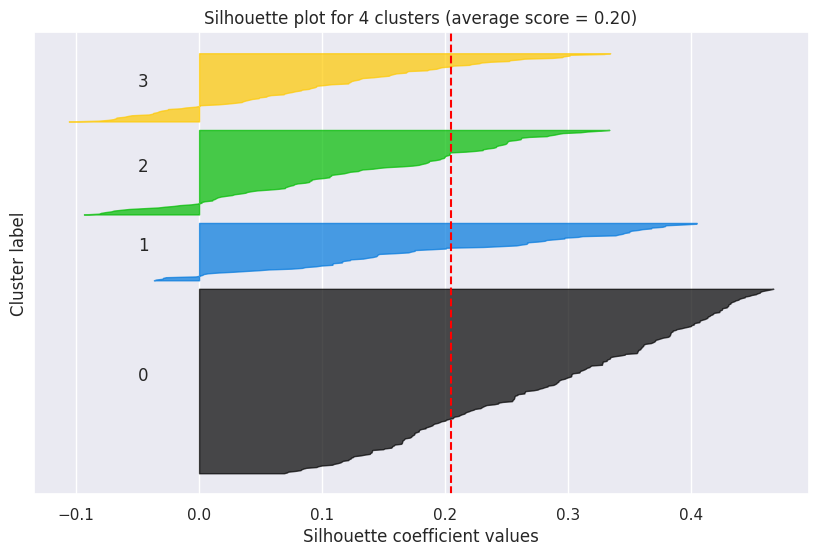

In [47]:
# visualizing silhouette scores for a few candidate values of k
silhouette_plot(subset_scaled_df, 4)

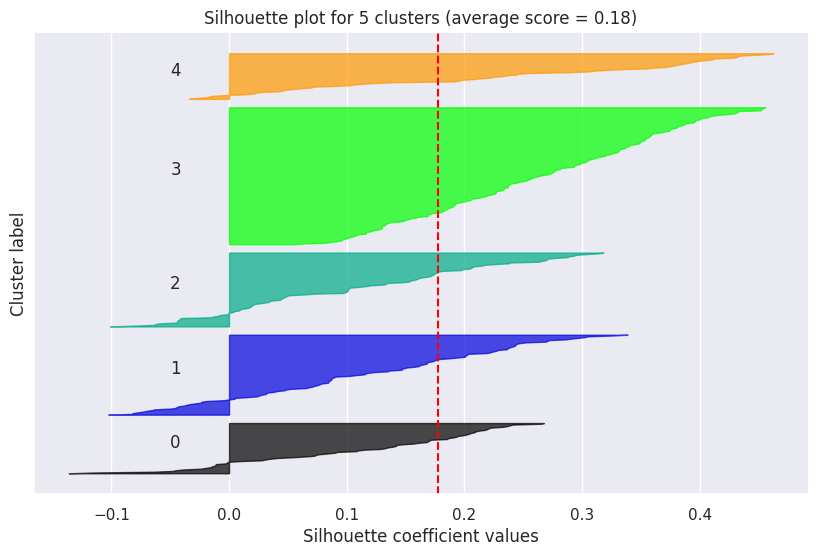

In [48]:
silhouette_plot(subset_scaled_df, 5)

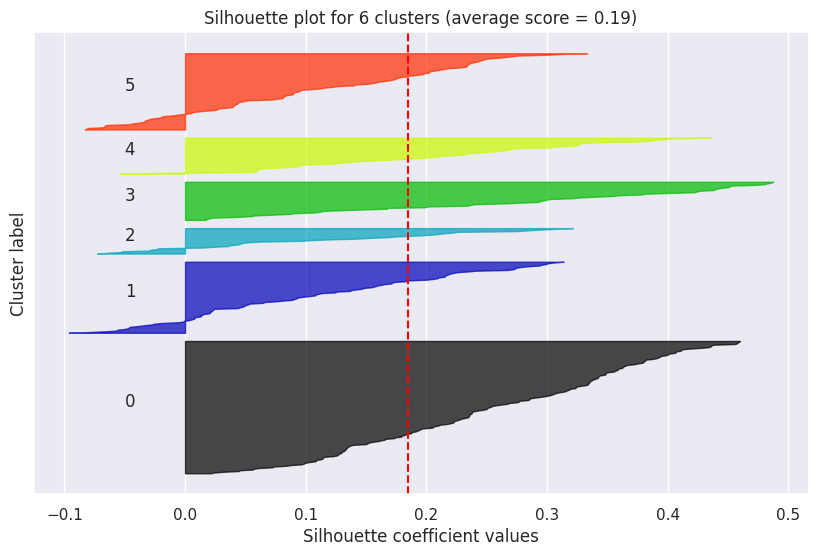

In [49]:
silhouette_plot(subset_scaled_df, 6)

- Based on the elbow method and the silhouette scores, k=4 is chosen as the appropriate number of clusters, since it provides a good balance between compact clusters and a manageable number of segments

In [50]:
# fitting the final K-Means model with k=4
kmeans = KMeans(n_clusters=4, random_state=1, n_init=10)
kmeans.fit(subset_scaled_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [51]:
# adding the cluster labels back to the data
df_treated["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

In [52]:
# profiling the clusters using the mean of each attribute
cluster_profile = df_treated.groupby("K_means_segments").mean(numeric_only=True)
cluster_profile["count_in_each_segment"] = (
    df_treated.groupby("K_means_segments")["Security"].count().values
)
cluster_profile

,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio,count_in_each_segment
K_means_segments,,,,,,,,,,,,
0,103.022221,5.614922,8.051872,15.798515,21.846514,5.669139e+08,1.290457e+09,4.314586,5.264023e+08,28.320642,3.375649,239
1,186.655567,1.670335,14.798499,24.811093,22.560209,4.868906e+09,5.569817e+09,7.903220,1.261456e+09,23.978710,5.601660,75
2,96.644380,14.851698,58.202908,19.012936,68.686077,3.474586e+08,4.643731e+08,0.709440,5.378714e+08,49.918478,8.646289,110
3,372.245957,15.294858,31.167527,43.119112,44.080391,2.323031e+09,2.896682e+09,11.787907,3.605249e+08,38.162047,14.246667,89


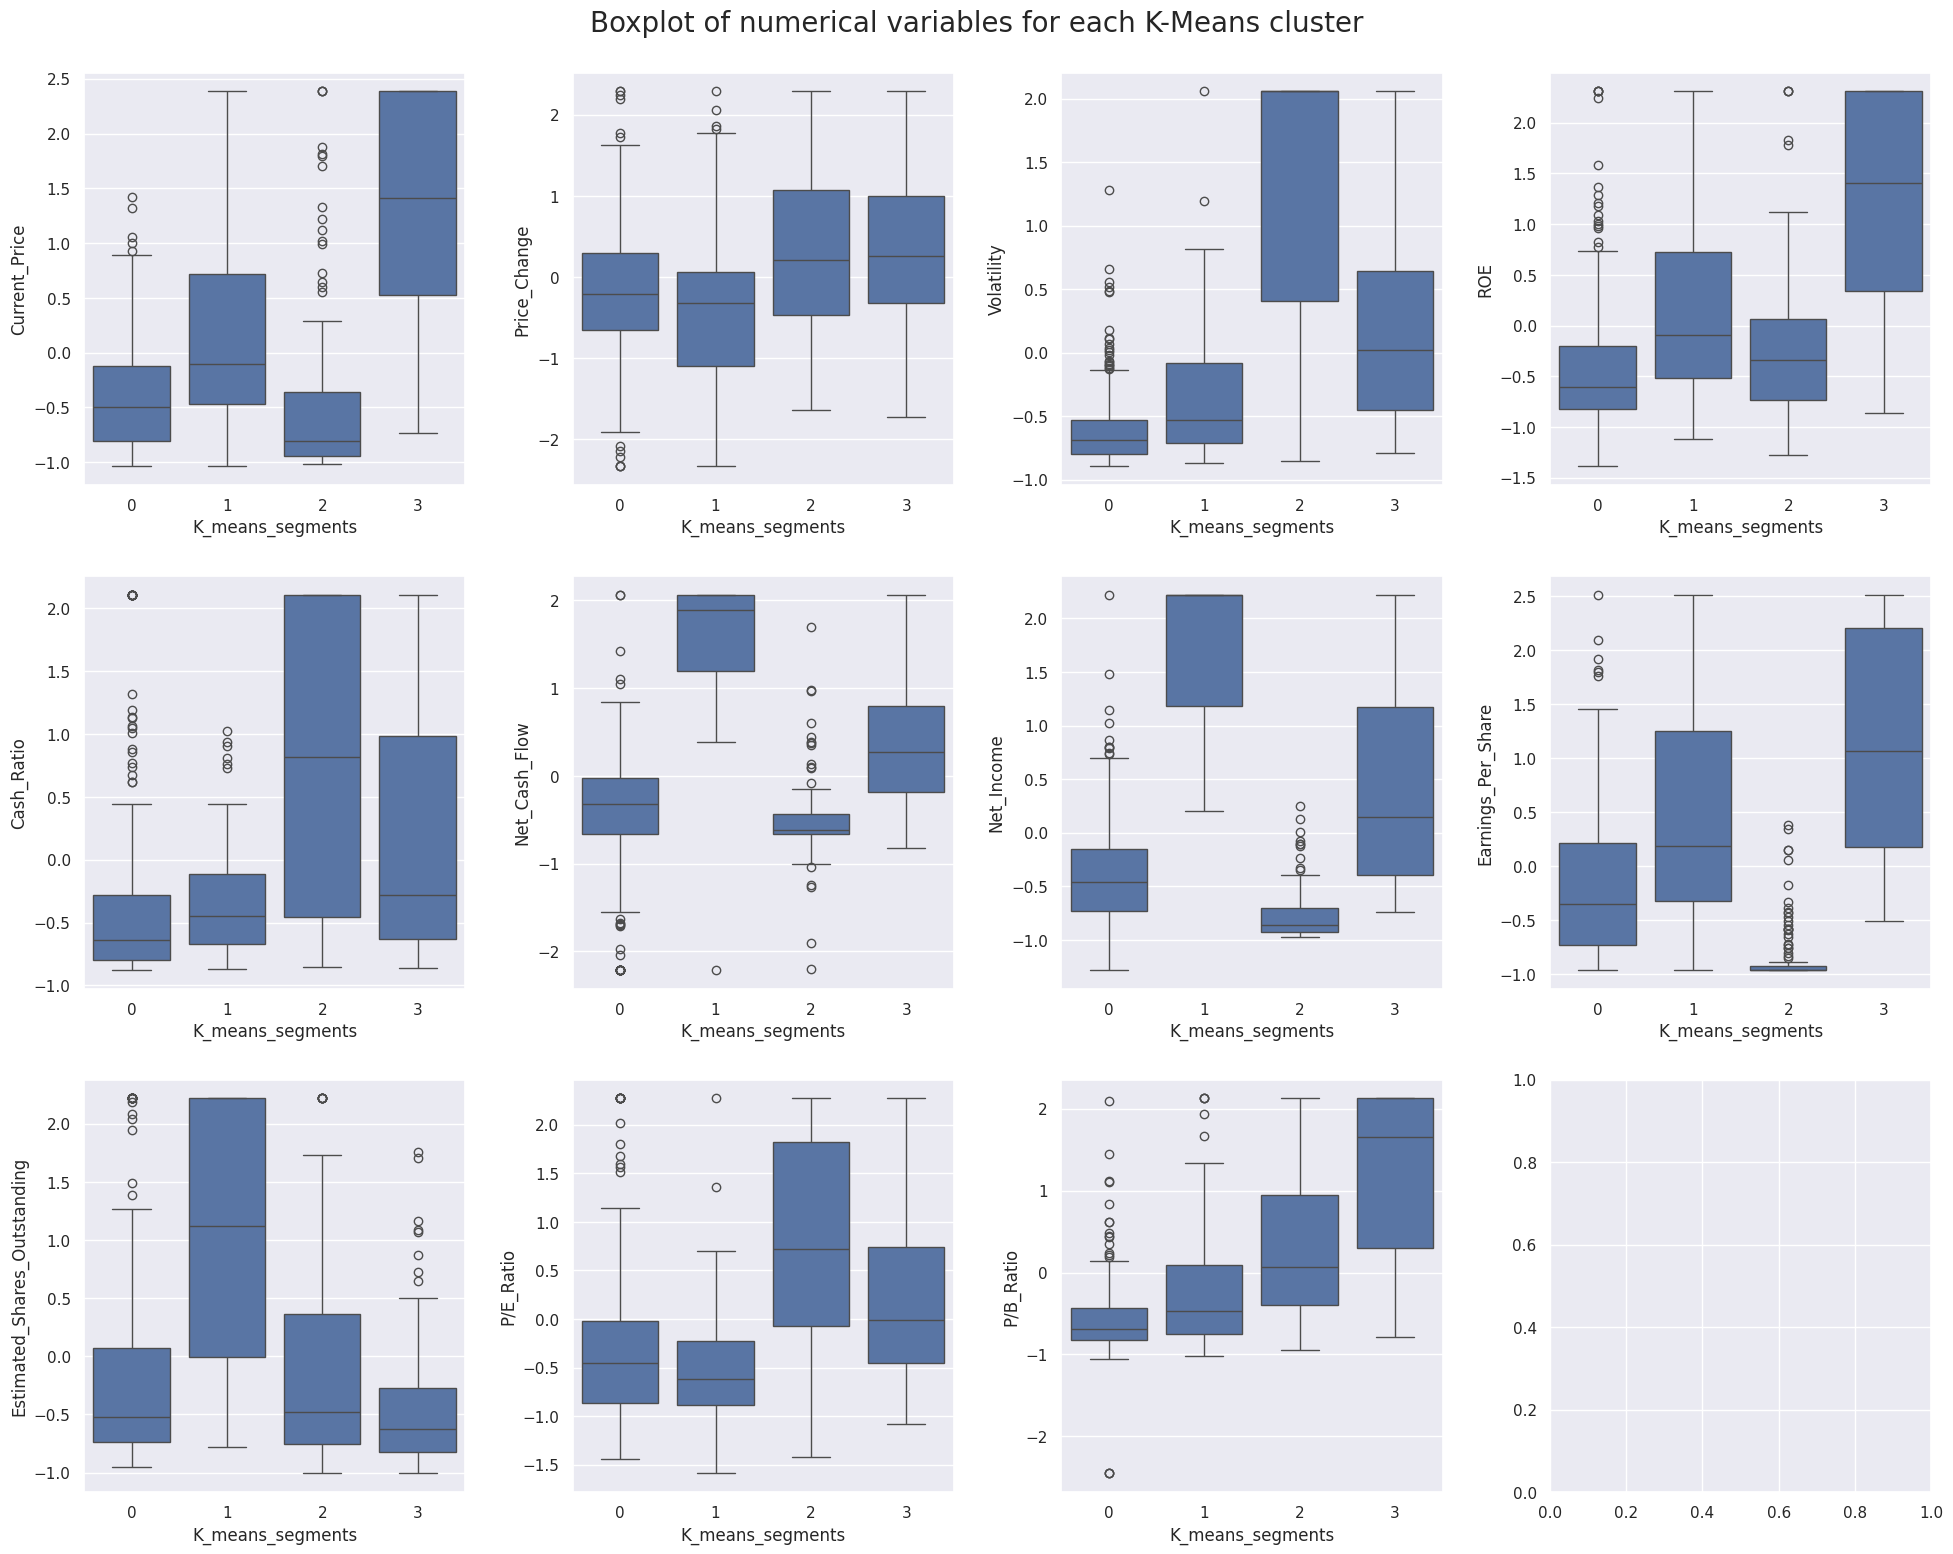

In [53]:
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
fig.suptitle("Boxplot of numerical variables for each K-Means cluster", fontsize=20)
counter = 0
for ii in range(3):
    for jj in range(4):
        if counter < len(num_cols):
            sns.boxplot(
                ax=axes[ii, jj],
                y=subset_scaled_df[num_cols[counter]],
                x=subset_scaled_df["K_means_segments"],
            )
        counter = counter + 1
fig.tight_layout(pad=2.0)
plt.show()

In [54]:
# comparing clusters against GICS_Sector
pd.crosstab(df_treated.GICS_Sector, df_treated.K_means_segments).style.highlight_max(
    color="lightgreen", axis=0
)

K_means_segments,0,1,2,3
GICS_Sector,,,,
Communication Services,7,11,1,0
Consumer Discretionary,18,4,16,12
Consumer Staples,19,4,11,5
Energy,14,11,1,2
Financials,13,6,5,5
Health Care,24,14,21,7
Industrials,39,8,15,26
Information Technology,18,14,26,25
Materials,23,2,5,2


## K-Means Insights

- Cluster profiles differ meaningfully in average Current_Price, Volatility, ROE, Cash_Ratio, Net_Income and P/E_Ratio, which shows that the clusters are capturing real differences in company size, risk and profitability
- The cross-tabulation with GICS_Sector shows that some clusters are dominated by specific sectors, while at least one cluster is broad and diversified across sectors

## Hierarchical Clustering

In [55]:
# comparing cophenetic correlation across distance metrics and linkage methods
distance_metrics = ["euclidean", "chebyshev", "cityblock"]
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df.drop("K_means_segments", axis=1), metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df.drop("K_means_segments", axis=1)))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.5951262702067358
Cophenetic correlation for Euclidean distance and complete linkage is 0.5828006492775974
Cophenetic correlation for Euclidean distance and average linkage is 0.7212543590332617
Cophenetic correlation for Euclidean distance and weighted linkage is 0.5846969079652097
Cophenetic correlation for Chebyshev distance and single linkage is 0.592190113911908
Cophenetic correlation for Chebyshev distance and complete linkage is 0.3373791531111483
Cophenetic correlation for Chebyshev distance and average linkage is 0.6393825750484174
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.36824002317252685
Cophenetic correlation for Cityblock distance and single linkage is 0.5681037670008819
Cophenetic correlation for Cityblock distance and complete linkage is 0.5345431320194435
Cophenetic correlation for Cityblock distance and average linkage is 0.6871307312506453
Cophenetic correlation for Cit

In [56]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.7212543590332617, which is obtained with Euclidean distance and average linkage


In [57]:
# comparing cophenetic correlation across linkage methods for Euclidean distance
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

hc_data = subset_scaled_df.drop("K_means_segments", axis=1)

for lm in linkage_methods:
    Z = linkage(hc_data, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(hc_data))
    print("Cophenetic correlation for {} linkage is {}".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.5951262702067358
Cophenetic correlation for complete linkage is 0.5828006492775974
Cophenetic correlation for average linkage is 0.7212543590332617
Cophenetic correlation for centroid linkage is 0.7231960581257083
Cophenetic correlation for ward linkage is 0.5741161651119461
Cophenetic correlation for weighted linkage is 0.5846969079652097


In [58]:
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.7231960581257083, which is obtained with centroid linkage


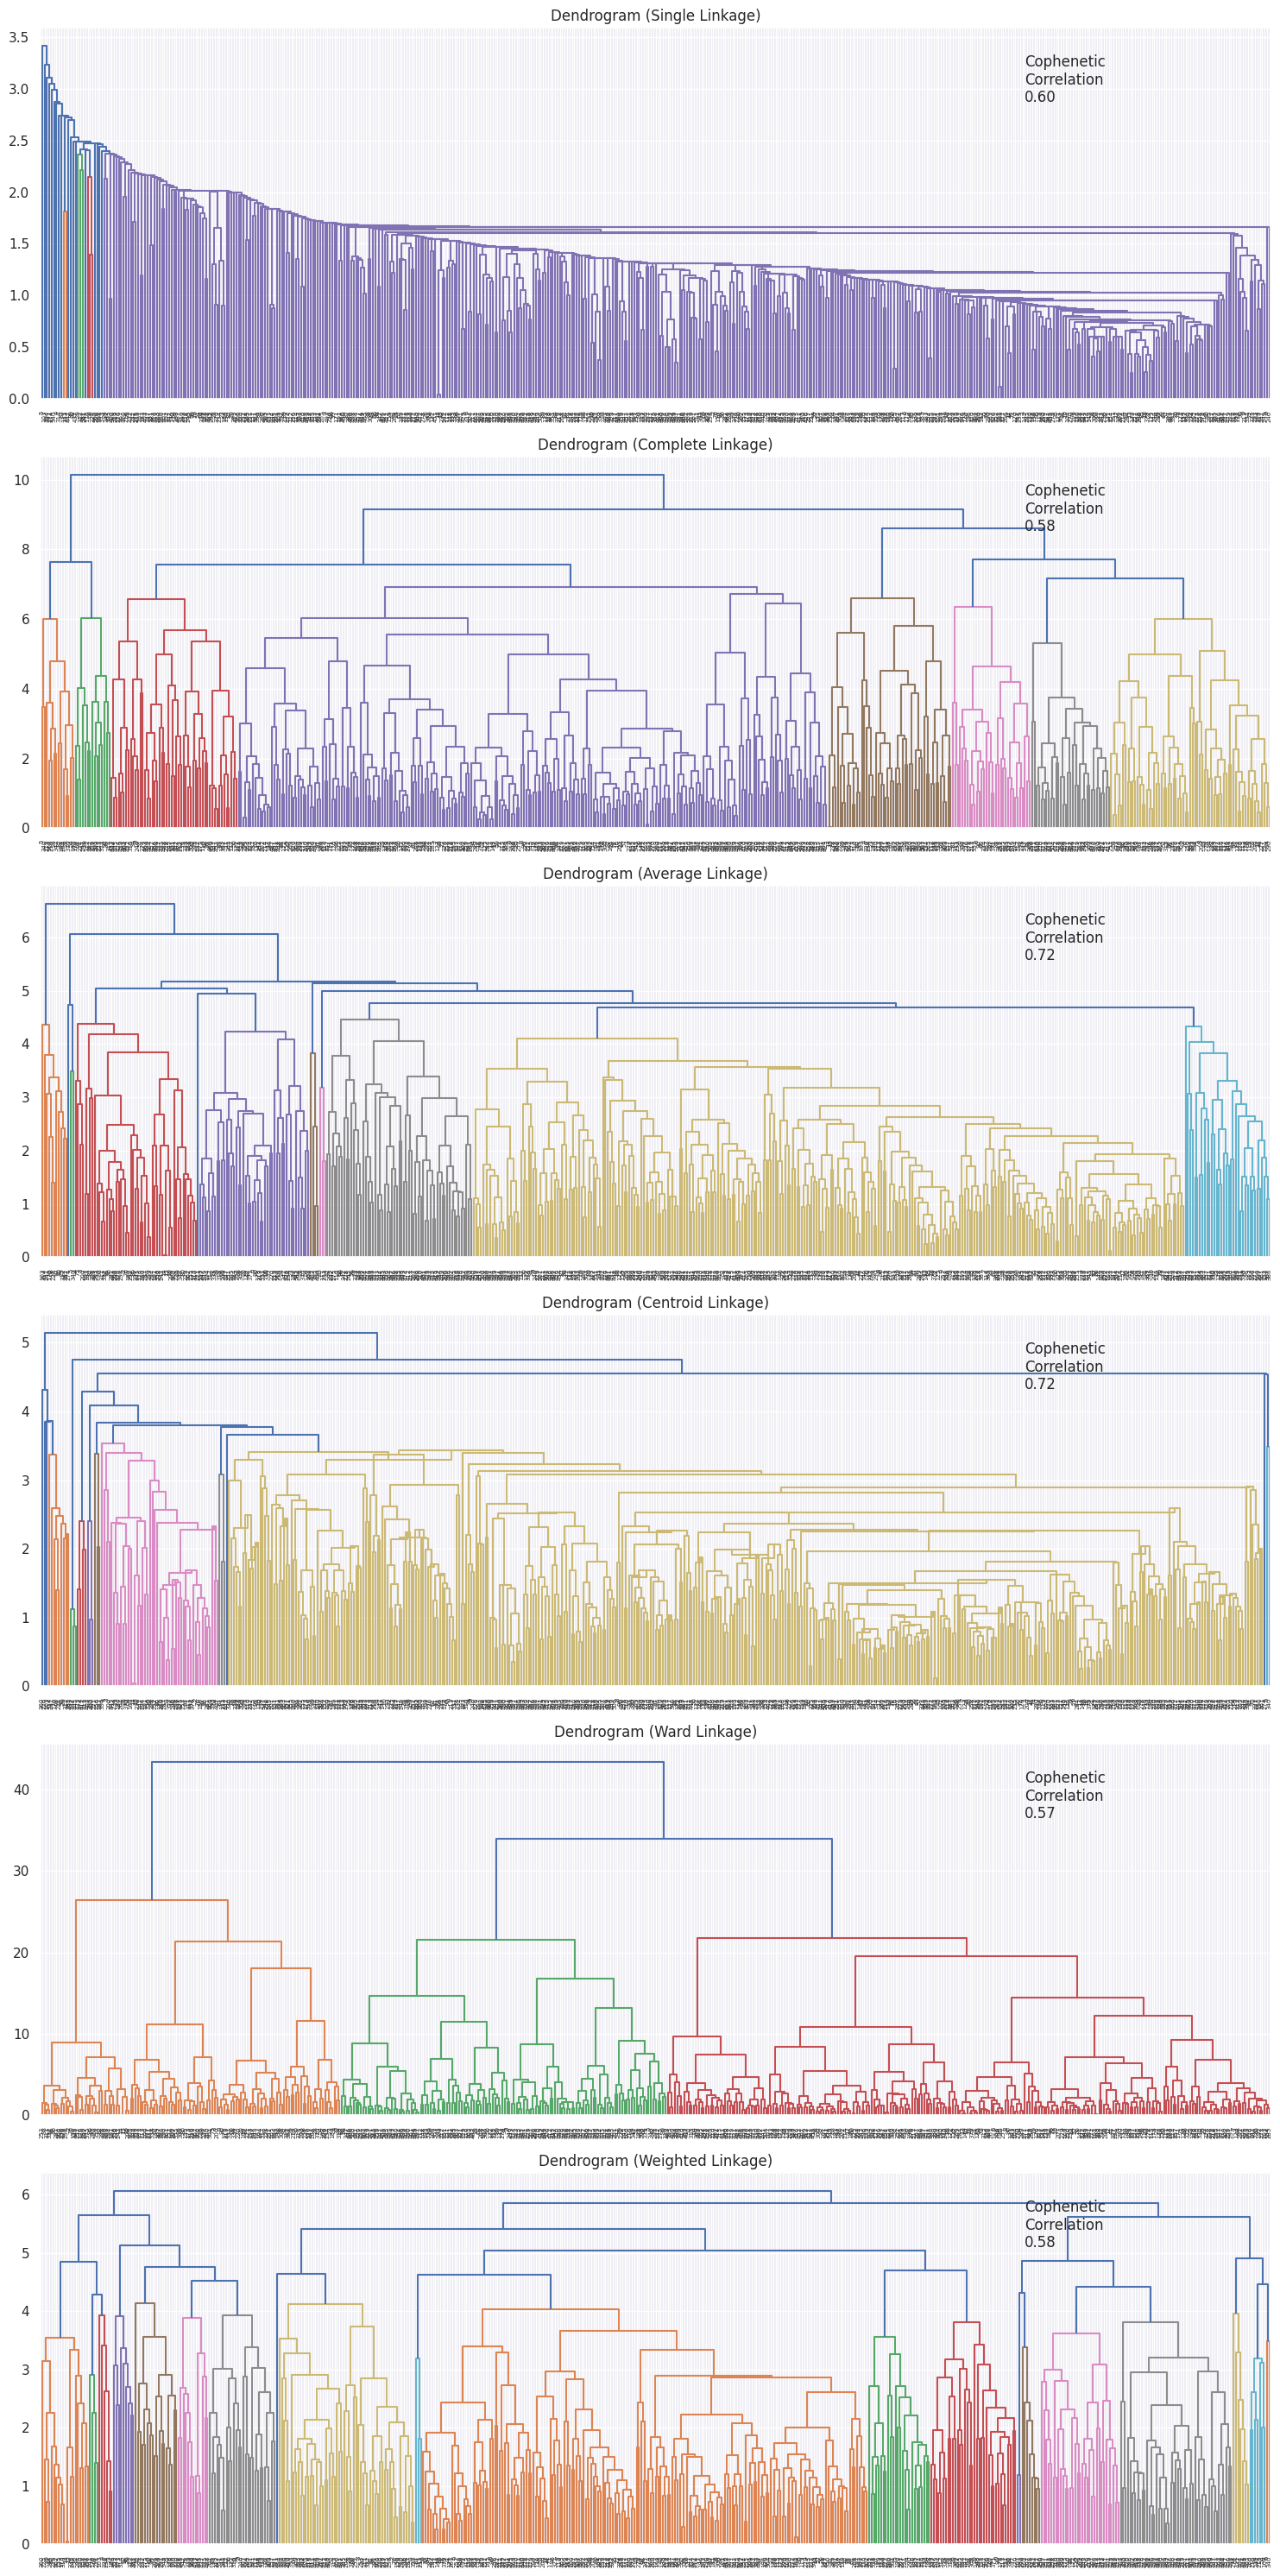

In [59]:
# plotting dendrograms for each linkage method with Euclidean distance
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

for i, method in enumerate(linkage_methods):
    Z = linkage(hc_data, metric="euclidean", method=method)
    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")
    coph_corr, coph_dist = cophenet(Z, pdist(hc_data))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

plt.tight_layout()
plt.show()

- Cophenetic correlation is highest with Euclidean distance and average or centroid linkage, but these linkages do not produce well-separated, well-populated clusters
- Ward linkage produces more distinct, better balanced clusters, and 4 appears to be an appropriate number of clusters from its dendrogram, which also keeps the choice consistent with the K-Means result

In [60]:
# fitting Agglomerative Clustering with average linkage first, as a check
HCmodel = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="average")
HCmodel.fit(hc_data)

df_treated["HC_Clusters_avg"] = HCmodel.labels_
df_treated["HC_Clusters_avg"].value_counts()

HC_Clusters_avg
0    401
1     98
3     11
2      3
Name: count, dtype: int64

- Average linkage results in a few clusters with very few securities, which does not give a usable segmentation. Ward linkage is used instead, since it produces clusters with meaningful variability and size

In [61]:
# fitting the final Hierarchical Clustering model using Ward linkage
HCmodel = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="ward")
HCmodel.fit(hc_data)

df_treated["HC_Clusters"] = HCmodel.labels_
subset_scaled_df["HC_Clusters"] = HCmodel.labels_
df_treated.drop("HC_Clusters_avg", axis=1, inplace=True)

In [62]:
# profiling the Hierarchical Clustering clusters
cluster_profile = df_treated.groupby("HC_Clusters").mean(numeric_only=True)
cluster_profile["count_in_each_segment"] = (
    df_treated.groupby("HC_Clusters")["Security"].count().values
)
cluster_profile

,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio,K_means_segments,count_in_each_segment
HC_Clusters,,,,,,,,,,,,,
0,102.614914,6.538404,11.334102,14.754972,17.239676,7.867625e+08,1.506204e+09,3.885881,6.419355e+08,30.694163,3.360549,0.301587,252
1,351.351253,10.350390,27.637574,42.840216,31.695183,2.865838e+09,3.481643e+09,13.276665,3.921379e+08,29.963371,12.652040,2.375000,88
2,145.123194,13.727783,47.975973,22.627522,77.388264,6.692709e+08,8.575440e+08,2.597451,4.182012e+08,45.693145,9.316525,1.764706,136
3,158.584520,0.991355,10.742760,27.031513,19.826415,5.517618e+09,6.282903e+09,6.763452,1.581640e+09,23.473463,5.909848,1.000000,37


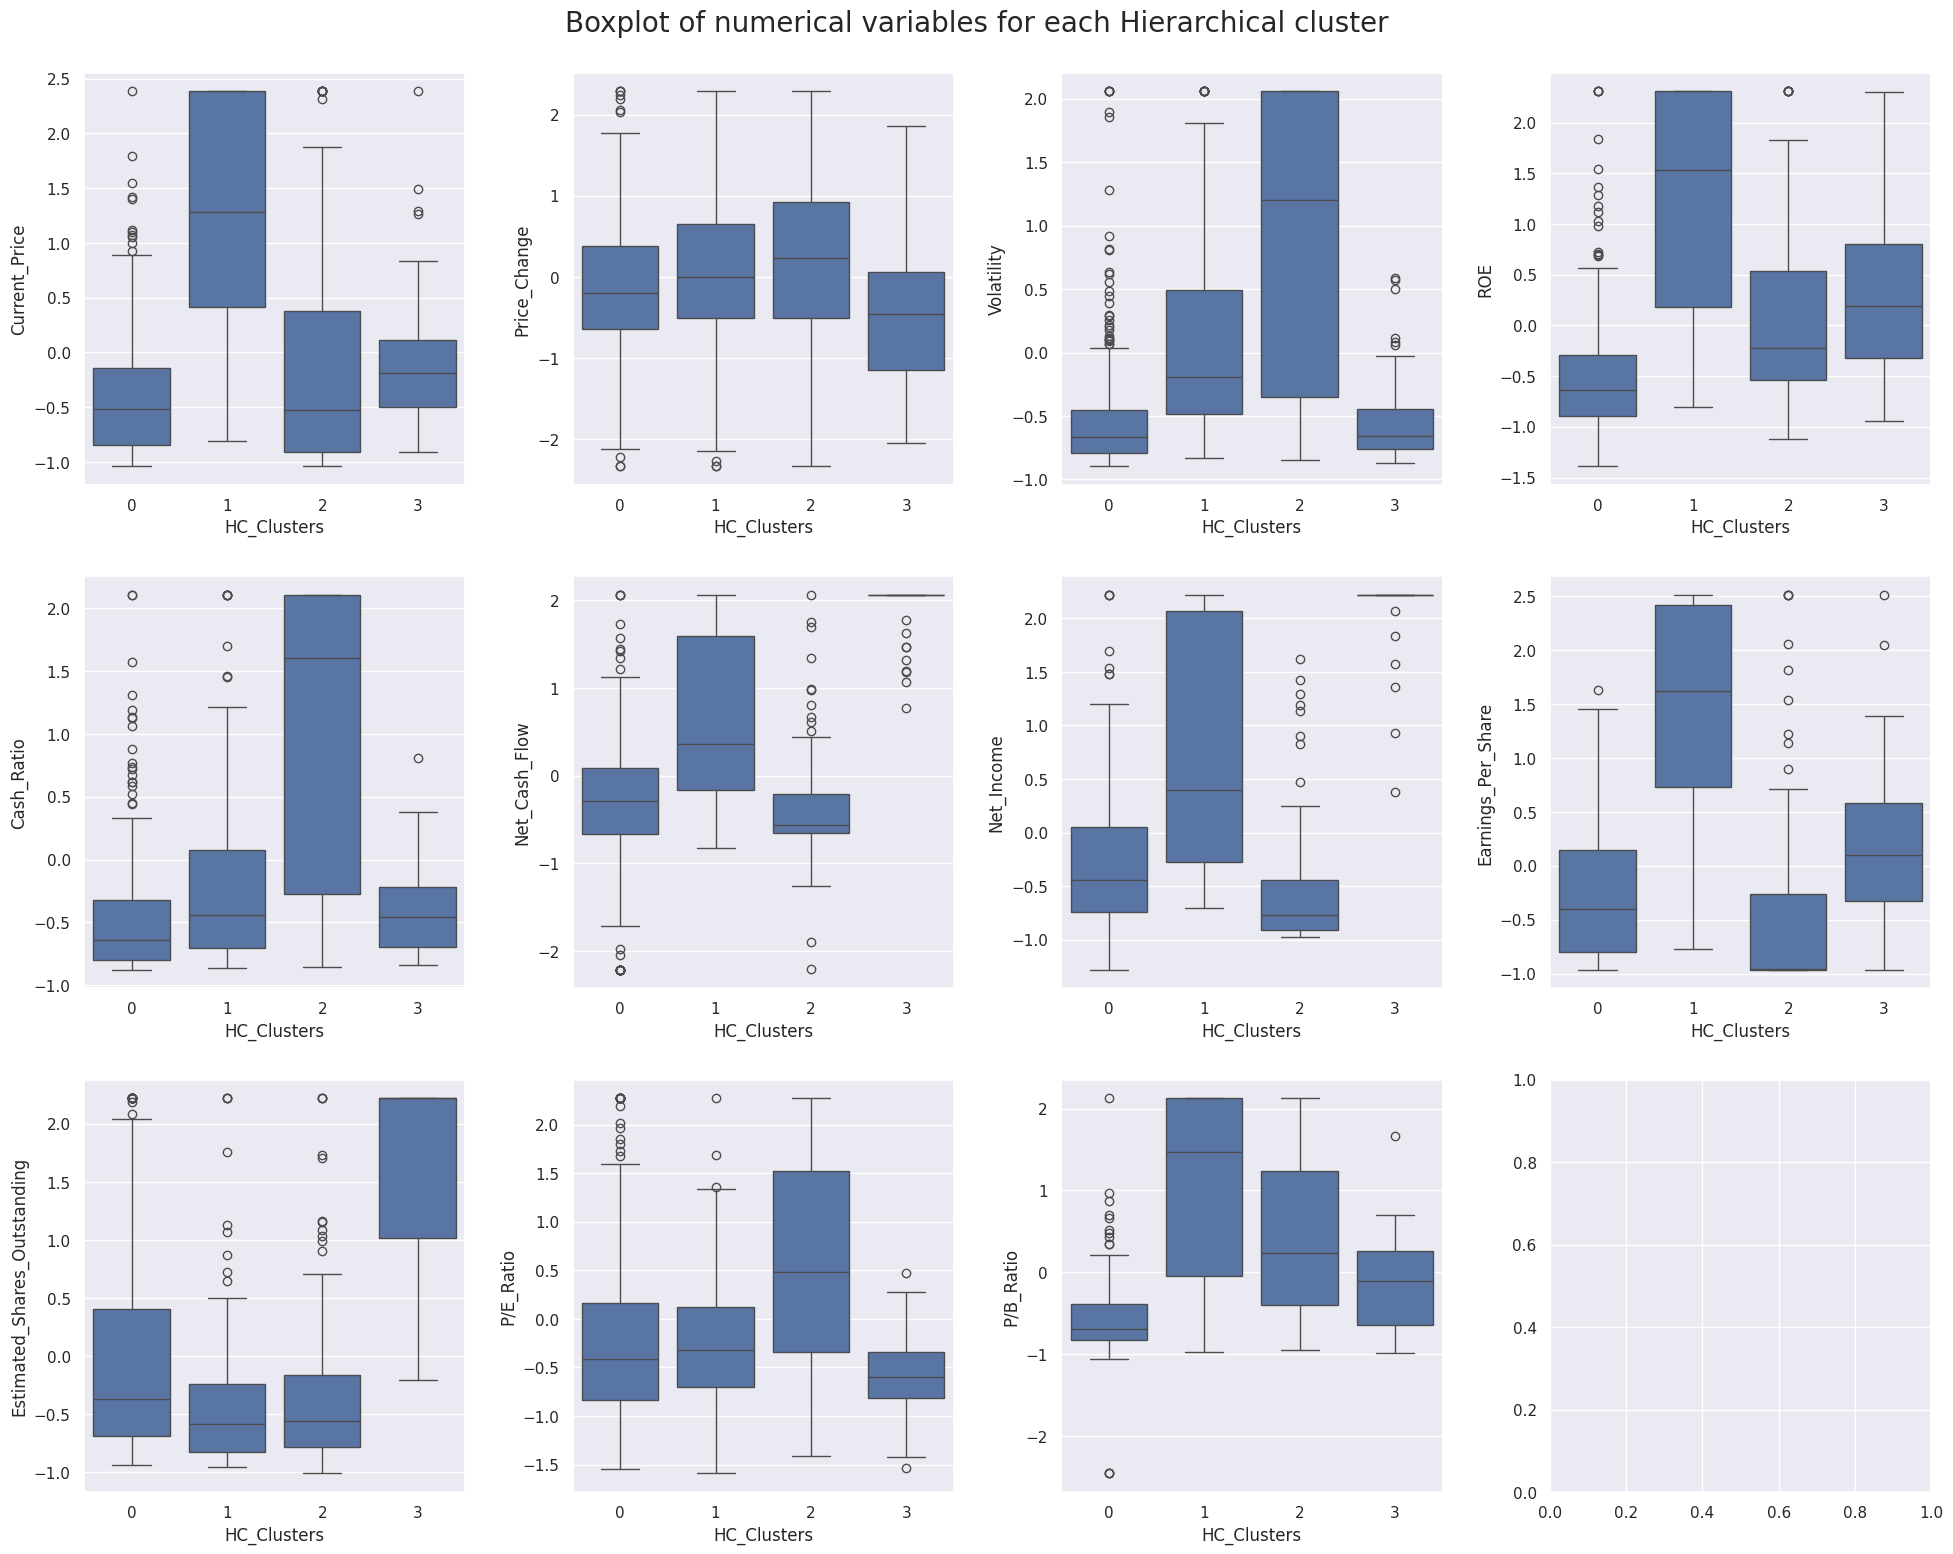

In [63]:
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
fig.suptitle("Boxplot of numerical variables for each Hierarchical cluster", fontsize=20)
counter = 0
for ii in range(3):
    for jj in range(4):
        if counter < len(num_cols):
            sns.boxplot(
                ax=axes[ii, jj],
                y=subset_scaled_df[num_cols[counter]],
                x=subset_scaled_df["HC_Clusters"],
            )
        counter = counter + 1
fig.tight_layout(pad=2.0)
plt.show()

In [64]:
# comparing Hierarchical clusters against GICS_Sector
pd.crosstab(df_treated.GICS_Sector, df_treated.HC_Clusters).style.highlight_max(
    color="lightgreen", axis=0
)

HC_Clusters,0,1,2,3
GICS_Sector,,,,
Communication Services,6,1,2,10
Consumer Discretionary,16,12,20,2
Consumer Staples,23,5,7,4
Energy,20,3,2,3
Financials,10,9,9,1
Health Care,25,9,25,7
Industrials,38,22,24,4
Information Technology,23,21,34,5
Materials,24,3,4,1


- The sector composition of the Hierarchical clusters is broadly similar to what was observed with K-Means, which is a good sign that the segmentation is picking up genuine structure in the data rather than an artifact of one particular algorithm

## K-Means vs Hierarchical Clustering

In [65]:
# comparing K-Means clusters against Hierarchical clusters
comparison = pd.crosstab(df_treated.K_means_segments, df_treated.HC_Clusters)
comparison.style.highlight_max(color="lightgreen", axis=0)

HC_Clusters,0,1,2,3
K_means_segments,,,,
0,207,7,25,0
1,19,17,2,37
2,21,0,89,0
3,5,64,20,0


In [66]:
# calculating how many securities were grouped identically by both methods
agreement = comparison.values.max(axis=1).sum()
total = comparison.values.sum()
print(
    "K-Means and Hierarchical Clustering grouped {} out of {} securities ({:.1f}%) in an identical fashion".format(
        agreement, total, 100 * agreement / total
    )
)

K-Means and Hierarchical Clustering grouped 397 out of 513 securities (77.4%) in an identical fashion


## Dimensionality Reduction using PCA for Visualization

In [67]:
# reducing the data to two dimensions for visualization
pca = PCA(n_components=2, random_state=1)
X_reduced_pca = pca.fit_transform(hc_data)
reduced_df_pca = pd.DataFrame(X_reduced_pca, columns=["Component 1", "Component 2"])

print("Variance explained by the first two components:", pca.explained_variance_ratio_.sum())

Variance explained by the first two components: 0.49227001758269406


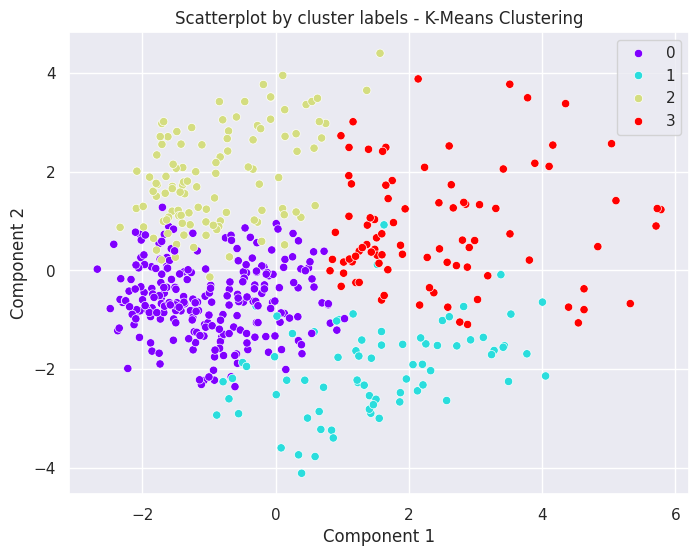

In [68]:
# scatterplot by K-Means cluster labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=reduced_df_pca,
    x="Component 1",
    y="Component 2",
    hue=df_treated["K_means_segments"],
    palette="rainbow",
)
plt.title("Scatterplot by cluster labels - K-Means Clustering")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

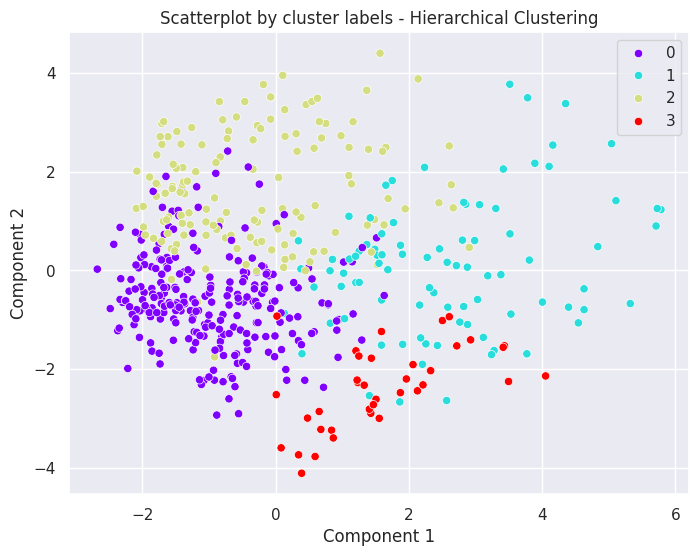

In [69]:
# scatterplot by Hierarchical cluster labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=reduced_df_pca,
    x="Component 1",
    y="Component 2",
    hue=df_treated["HC_Clusters"],
    palette="rainbow",
)
plt.title("Scatterplot by cluster labels - Hierarchical Clustering")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

- Both clustering methods produce well-separated clusters in the reduced two-dimensional space, with one large cluster containing most of the data points and the remaining clusters capturing distinct groups of outlying, higher-risk or higher-performing companies

## Insights and Recommendations

### Exploratory Data Analysis

- Current_Price, Volatility, ROE, Cash_Ratio and Estimated_Shares_Outstanding are all right skewed with several extreme outliers, which is expected in a cross-section of companies of very different sizes
- Sector labels pulled from a live source needed standardization before they matched the GICS classification used in sector-level analysis
- Sector composition of Price_Change, Cash_Ratio and P/E_Ratio varies meaningfully, which supports doing a sector-aware segmentation rather than treating all companies the same way

### Outlier Treatment

- A small number of extreme values in Volatility, ROE and a few other columns were far enough from the rest of the data to distort distance-based clustering
- Capping these values at the IQR whiskers (instead of removing the rows) preserved all companies in the dataset while making the clustering more robust and the resulting clusters more meaningful

### Clustering

- Both K-Means and Hierarchical clustering (Ward linkage) converge on 4 clusters as the appropriate segmentation, and the two methods agree on the grouping for the large majority of securities
- The clusters differentiate companies along risk (Volatility, Price_Change), profitability (ROE, Net_Income, Earnings_Per_Share) and valuation (P/E_Ratio, P/B_Ratio), which are exactly the dimensions an investor cares about when building a diversified portfolio

### Recommendations

- Investors should treat the resulting clusters as candidate buckets for diversification: pick a mix of securities across clusters rather than concentrating on a single cluster, so the portfolio is not overexposed to one risk/return profile
- Since market conditions change, this clustering should be refreshed periodically with updated data rather than treated as a one-time exercise, so that a company's segment reflects its current financial position rather than a historical snapshot
- Any single company that lands in a small, high-risk cluster should be reviewed individually before making a significant allocation decision, since small clusters are more sensitive to the specific companies they contain